# Đồ Án Machine Learning — Predict Delivery Time
## Mô tả bài toán
**Olist** là nền tảng thương mại điện tử lớn nhất tại Brazil. Mạng lưới hậu cần (logistics) của Brazil rất phức tạp do vị trí địa lý rộng lớn và cơ sở hạ tầng phân tán. Điều này dẫn đến sự chênh lệch lớn về thời gian giao hàng.

**Mục tiêu của bài toán (Regression):** 
Xây dựng mô hình Machine Learning dự đoán **thời gian giao hàng (Delivery Time)** — tính từ lúc khách hàng bấm nút "Cửa hàng/Đặt mua" (Order Purchase) đến khi nhận được hàng tận tay (Delivered to Customer). 

Thông qua quá trình khai phá dữ liệu (EDA), Feature Engineering và huấn luyện mô hình, chúng ta sẽ nhận diện được các "nút thắt" và tối ưu hóa hệ thống Logistics của nền tảng Olist.


## Table of Contents (Pipeline)

| # | Giai đoạn (Phase) | Nội dung chi tiết |
|---|---|---|
| 0 | Setup & Config | Cài đặt Môi trường, Đường dẫn & Load 7 bảng dữ liệu cốt lõi |
| 1 | Data Integration | Hợp nhất Left-join 6 bảng & Gom nhóm đơn hàng (Groupby) thu gọn |
| 2 | Cleaning & Target | Chuẩn hóa, Khởi tạo biến dự báo (Target) và Cắt bỏ Ngoại lai > 60 ngày |
| 3 | Exploratory Data Analysis | Vẽ biểu đồ Khai phá nguyên nhân chậm trễ (Khối lượng, Địa lý, Thời vụ) |
| 4 | Feature Engineering | Giải mã Insight thành Đặc trưng Toán học (Khoảng cách Haversine, Flags...) |
| 5 | Leakage Audit | Quét chống Rò rỉ dữ liệu (Xóa sạch các timestamp rác và ID chướng ngại) |
| 6 | Cross Validation Split | Temporal Split (Kỹ thuật cắt Tàu hỏa: Train/Val/Test theo trục Thời gian) |
| 7 | Missing & Encoding | Target Encoding K-Fold, Xử lý Giá trị trống (Tuyệt đối chỉ fit trên Train) |
| 8 | Transformation | Chuẩn hóa Robust Scaling & Biến đổi độ lệch Logarit (Log1p) |
| 9 | Multicollinearity & Baseline | Quét rác Đa cộng tuyến (VIF) & Sanity Check Feature Importances |
| 10 | Export Artifacts | Xuất Dataset sạch sẽ ra lò để nạp vào Linear Regression Model |


# 0a. IMPORT THƯ VIỆN & MODULES

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import joblib
import category_encoders as ce

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from utils import read_data, filter_and_clean_order_status, initialize_target_variable
from utils import optimize_logistics_timestamps , handle_category_missing, standardize_column_formats
from utils import  visualize_outliers, plot_violin_comparison
from utils import merge_geolocation_and_calculate_distance, calculate_full_vif

# 0b. THAM SỐ CẤU HÌNH GLOBAL (CONFIG)

In [2]:
# ==========================================
# 0b. THAM SỐ CẤU HÌNH GLOBAL (CONFIG)
# ==========================================

class CFG:
    # --- Paths (Đường dẫn) ---
    DATA_PATH = "../../data/"
    OUTPUT_PATH = "./processed_data/"
    
    
    TARGET_COL = "target_delivery_days"
    RANDOM_STATE = 42
    
    
    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.10
    TEST_SIZE = 0.20
    
    # --- Data Processing Parameters ---
    TE_SMOOTHING = 10         # Target Encoder Smoothing value
    VIF_THRESHOLD = 5.0      # Ngưỡng tối đa cho Đa cộng tuyến
    OUTLIER_CUTOFF_DAYS = 60  # Đơn hàng > 60 ngày sẽ bị coi là nhiễu hệ thống


os.makedirs(CFG.OUTPUT_PATH, exist_ok=True)


if os.path.exists(CFG.DATA_PATH):
    print(f" Đã kết nối thành công thư mục Data: {CFG.DATA_PATH}")
    print(f" Thư mục xuất dữ liệu (Processed Data): {CFG.OUTPUT_PATH}")
else:
    print(f" LỖI: Không tìm thấy đường dẫn Data gốc: {CFG.DATA_PATH}")
    print(f"   Vui lòng kiểm tra lại cấu trúc thư mục của bạn!")

 Đã kết nối thành công thư mục Data: ../../data/
 Thư mục xuất dữ liệu (Processed Data): ./processed_data/


#  0c. LOAD DỮ LIỆU & DATA DICTIONARY

Khởi tạo và kết nối nối các bảng dữ liệu độc lập của hệ thống Olist.

### a. Orders Data (Dữ liệu Đơn hàng cốt lõi)

Bảng này chứa thông tin về các đơn hàng được khách hàng đặt trên các nền tảng thương mại điện tử. Mỗi dòng đại diện cho một đơn hàng riêng biệt của khách hàng 
<div align="center">

| Feature                          | Mô tả                                                                 |
|----------------------------------|----------------------------------------------------------------------|
| order_id                         | Mã định danh duy nhất cho mỗi đơn hàng                              |
| customer_id                      | Mã định danh duy nhất của khách hàng đặt đơn                        |
| order_status                     | Trạng thái hiện tại của đơn hàng (ví dụ: đã giao, đang giao, đã hủy)|
| order_purchase_timestamp         | Thời điểm khách hàng đặt đơn hàng                                   |
| order_approved_at                | Thời điểm đơn hàng được xác nhận                                    |
| order_delivered_carrier_date     | Thời điểm đơn hàng được bàn giao cho đơn vị vận chuyển              |
| order_delivered_customer_date    | Thời điểm đơn hàng được giao đến khách hàng                         |
| order_estimated_delivery_date    | Ngày dự kiến giao hàng                                              |
</div>

In [3]:
orders_df = read_data(CFG.DATA_PATH, "olist_orders_dataset.csv")
print('Orders Data Shape: ',orders_df.shape)
display(orders_df.head())
print("Orders Data Info:")
display(orders_df.info())

Đang đọc dữ liệu từ olist_orders_dataset.csv...
Orders Data Shape:  (99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Orders Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

### **b. Orders items**

Bảng này chứa thông tin về các mặt hàng được đặt mua trong hệ thống thương mại điện tử. Mỗi hàng đại diện cho một mặt hàng trong một đơn đặt hàng.
<div align='center'>

| Feature              | Mô tả                                                                 |
|---------------------|----------------------------------------------------------------------|
| order_id            | Mã định danh duy nhất của đơn hàng                                   |
| order_item_id       | Số thứ tự của từng sản phẩm trong cùng một đơn hàng                  |
| product_id          | Mã định danh duy nhất của sản phẩm                                   |
| seller_id           | Mã định danh duy nhất của người bán sản phẩm                         |
| shipping_limit_date | Hạn chót để sản phẩm được gửi đi                                    |
| price               | Giá của sản phẩm                                                     |
| freight_value       | Chi phí vận chuyển của sản phẩm                                     |

</div>

In [4]:
order_items_df = read_data(CFG.DATA_PATH, "olist_order_items_dataset.csv")
print("Orders items Data Shape: ", order_items_df.shape)
display(order_items_df.head())
print("Orders items Data Info:")
display(order_items_df.info())  

Đang đọc dữ liệu từ olist_order_items_dataset.csv...
Orders items Data Shape:  (112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Orders items Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


None

### **c. Customers** 

Bảng này chứa thông tin về khách hàng. Mỗi hàng trong bảng đại diện cho một khách hàng, mỗi khách hàng được xác định bằng các thuộc tính hoặc đặc điểm được thể hiện bởi các cột trong bảng.
<div align='center'>

| Feature                    | Mô tả                                                                 |
|---------------------------|----------------------------------------------------------------------|
| customer_id               | Mã định danh duy nhất cho mỗi lần giao dịch hoặc tương tác của khách hàng |
| customer_unique_id        | Mã định danh duy nhất cho mỗi khách hàng                             |
| customer_zip_code_prefix  | Tiền tố mã bưu điện của địa chỉ khách hàng                          |
| customer_city             | Thành phố của khách hàng                                             |
| customer_state            | Bang (khu vực) của khách hàng                                        |

</div>

In [5]:
customers_df = read_data(CFG.DATA_PATH, "olist_customers_dataset.csv")   
print("Customers Data Shape: ", customers_df.shape)
display(customers_df.head())
print("Customers Data Info:")
display(customers_df.info())  

Đang đọc dữ liệu từ olist_customers_dataset.csv...
Customers Data Shape:  (99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Customers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

### **d. Sellers**

Bảng này cung cấp thông tin về người bán đã đăng ký ở trên nền tảng bán hàng. Mỗi dòng mô tả chi tiết về một người bán 
<div align='center'>

| Feature                 | Mô tả                                                           |
|------------------------|-----------------------------------------------------------------|
| seller_id              | Mã định danh duy nhất cho mỗi người bán                         |
| seller_zip_code_prefix | Tiền tố mã bưu điện của địa chỉ người bán                      |
| seller_city            | Thành phố nơi người bán hoạt động                               |
| seller_state           | Bang (khu vực) nơi người bán hoạt động                          |

</div>

In [6]:
sellers_df = read_data(CFG.DATA_PATH, "olist_sellers_dataset.csv")
print("Sellers Data Shape: ", sellers_df.shape)
display(sellers_df.head())
print("Sellers Data Info:")
display(sellers_df.info())

Đang đọc dữ liệu từ olist_sellers_dataset.csv...
Sellers Data Shape:  (3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Sellers Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

### **e. Products**

Bảng này chứa tập hợp dữ liệu sản phẩm từ các nền tảng thương mại điện tử, bao gồm thông tin về nhiều sản phẩm khác nhau như mô tả sản phẩm hoặc kích thước.
<div align='center'>

| Feature                        | Mô tả                                                                 |
|--------------------------------|----------------------------------------------------------------------|
| product_id                     | Mã định danh duy nhất của sản phẩm                                   |
| product_category_name          | Danh mục mà sản phẩm thuộc về                                        |
| product_name_lenght            | Độ dài tên sản phẩm (số ký tự)                                       |
| product_description_lenght     | Độ dài mô tả sản phẩm (số ký tự)                                     |
| product_photos_qty             | Số lượng hình ảnh của sản phẩm                                       |
| product_weight_g               | Trọng lượng sản phẩm (tính bằng gram)                               |
| product_length_cm              | Chiều dài sản phẩm (cm)                                              |
| product_height_cm              | Chiều cao sản phẩm (cm)                                              |
| product_width_cm               | Chiều rộng sản phẩm (cm)                                             |

</div>

In [7]:
products_df = read_data(CFG.DATA_PATH, "olist_products_dataset.csv")
print("Products Data Shape: ", products_df.shape)
display(products_df.head())
print("Products Data Info:")
display(products_df.info())

Đang đọc dữ liệu từ olist_products_dataset.csv...
Products Data Shape:  (32951, 9)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Products Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

### **f. Translation** 

Bảng này chứa tập dữ liệu dịch tên danh mục sản phẩm, được sử dụng để dịch tên danh mục sản phẩm từ tiếng Bồ Đào Nha sang tiếng Anh.
<div align='center'>

| Feature                         | Mô tả                                                      |
|---------------------------------|-----------------------------------------------------------|
| product_category_name           | Tên danh mục sản phẩm gốc bằng tiếng Bồ Đào Nha           |
| product_category_name_english   | Tên danh mục sản phẩm đã được dịch sang tiếng Anh         |

</div>

In [8]:
category_translation_df = read_data(CFG.DATA_PATH, "product_category_name_translation.csv")
print("Translation Data Shape: ", category_translation_df.shape)
display(category_translation_df.head())
print("Translation Data Info:")
display(category_translation_df.info())

Đang đọc dữ liệu từ product_category_name_translation.csv...
Translation Data Shape:  (71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Translation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

### **g. Geolocation** 
Bảng này chứa dữ liệu xác định vị trí địa lý trong thế giới thực hoặc vị trí vật lý của các đối tượng khác nhau thông qua tọa độ GPS. Mỗi hàng đại diện cho một vị trí địa lý duy nhất.

<div align='center'>

| Feature                       | Mô tả                                                                 |
|-------------------------------|----------------------------------------------------------------------|
| geolocation_zip_code_prefix   | Tiền tố mã bưu điện (CEP) của Brazil cho một khu vực cụ thể          |
| geolocation_lat              | Tọa độ vĩ độ của vị trí                                             |
| geolocation_lng              | Tọa độ kinh độ của vị trí                                           |
| geolocation_city             | Tên thành phố tương ứng với vị trí địa lý                           |
| geolocation_state            | Tên bang (khu vực) tương ứng với vị trí địa lý                      |

</div>

In [9]:
geolocation_df = read_data(CFG.DATA_PATH, "olist_geolocation_dataset.csv")
print("Geolocation Data Shape: ", geolocation_df.shape)
display(geolocation_df.head())
print("Geolocation Data Info:")
display(geolocation_df.info())

Đang đọc dữ liệu từ olist_geolocation_dataset.csv...
Geolocation Data Shape:  (1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Geolocation Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

# PHASE 1: DATA INTEGRATION (HỢP NHẤT DỮ LIỆU)
Trong tập dữ liệu Olist, quan hệ giữa tập `Orders` và `Order_Items` là quan hệ 1-Nhiều (1 đơn hàng có thể chứa nhiều sản phẩm). Ví dụ khách mua 3 món đồ trong cùng 1 giỏ hàng sẽ tạo ra 3 dòng trong bảng Items.
Nếu chỉ sử dụng lệnh Merge (Gộp) 6 bảng lại với nhau một cách đơn thuần, dữ liệu sẽ bị "phình to" theo cấp số nhân (Data Duplication). Mô hình học máy sẽ bị sai lệch khi phải học lặp lại cùng một đơn hàng nhiều lần. 
Do đó, tiến trình hợp nhất của chúng ta sẽ diễn ra theo 2 bước chặt chẽ:

1. **Merging:** Nối Left-Join 6 bảng lõi vào trục chính (`Orders`). *(Bảng thứ 7 là Geolocation sẽ được tách riêng xử lý ở Phase 3 ).*

2. **Aggregating (Groupby):** Gom nhóm dữ liệu theo `order_id` để trả Master Data về chuẩn **1 đơn hàng = 1 dòng**. Trong bước này, ta sẽ dùng phép Toán tương ứng cho từng tính chất: Cộng dồn tổng tiền hàng (`sum`), Lấy kích thước trung bình (`mean`), và Đếm tổng số lượng món (`count`).

In [10]:
# 1. Merge bảng 
df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
df = df.merge(order_items_df, on='order_id', how='left')
df = df.merge(sellers_df, on='seller_id', how='left')
df = df.merge(products_df, on='product_id', how='left')
df = df.merge(category_translation_df, on='product_category_name', how='left')

# 2. Gom nhóm  (1 đơn hàng = 1 dòng dữ liệu duy nhất, vì một đơn hàng có nhiều món, nhưng chỉ có 1 thời gian giao hàng cho đơn đó)
df_master = df.groupby('order_id').agg({
    'customer_id': 'first',
    'order_status': 'first',
    'order_purchase_timestamp': 'first',
    'order_approved_at': 'first',
    'order_delivered_carrier_date': 'first',
    'order_delivered_customer_date': 'first',
    'order_estimated_delivery_date': 'first',
    'customer_zip_code_prefix': 'first',
    'customer_state': 'first',
    'customer_city': 'first',
    
    
    'price': 'sum', # giá
    'freight_value': 'sum',
    'product_id': 'count', # mua bao món trong đơn 
    
    # Thông tin hàng hóa: Lấy món mang tính chất đại diện (Mode/Mean)
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'unknown',
    'product_weight_g': 'mean',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',
    
    # Thông tin Seller (Lấy Seller đầu tiên nếu 1 đơn mua từ nhiều shop)
    'seller_id': 'first',
    'seller_zip_code_prefix': 'first',
    'seller_state': 'first',
    'seller_city': 'first'
}).reset_index()
# Vì ta dùng product_id để đếm số sản phẩm, ta dùng lệnh Rename để trả lại tên chuẩn
df_master.rename(columns={'product_id': 'item_count'}, inplace=True)
print(f"Kích thước Master Data: {df_master.shape}")


Kích thước Master Data: (99441, 23)


#  PHASE 2: DATA CLEANING & TARGET ENGINEERING 

Dữ liệu thô luôn chứa nhiều nhiễu. Ở bước này, chúng ta sẽ làm sạch dữ liệu dựa trên logic Business thực tế của nghành Logistics:

1. **Fix Missing Thô & Ép kiểu:** Chạy Script dự phòng để vá các nhãn thời gian rỗng (`optimize_logistics_timestamps`) và vùi lấp các chuỗi ký tự phân loại vô danh (`handle_category_missing`). Sau đó ép kiểu Datetime.

2. **Lọc trạng thái đơn:** Chỉ giữ lại những đơn giao thành công (`status == 'delivered'`), loại bỏ đơn thất lạc.

3. **Target Engineering:** Cấu thành biến dự báo `target_delivery_days` từ độ trễ Thời gian nhận và Thời gian Đặt.

4. **Outlier Filtering:** Cắt đuôi ngoại lai (Loại bỏ các đơn trôi dạt vô lý > 60 ngày) để cứu vớt Mô hình Tuyến tính.

In [11]:
# điền thời gian rỗng 
df_cleaned = optimize_logistics_timestamps(df_master)

# điền ô rỗng (ngành hàng) thành 'other' 
df_cleaned = handle_category_missing(df_cleaned)

# Chuẩn hóa format 
df_cleaned = standardize_column_formats(df_cleaned)

# Lọc đơn hàng có trạng thái thành công 
df_cleaned = filter_and_clean_order_status(df_cleaned)

# Tính toán biến mục tiêu (delivery_time_days) lọc các lỗi logic (<0 ngày)
df_cleaned = initialize_target_variable(df_cleaned)

# Validate 
print("\n  VALIDATE TARGET DISTRIBUTION ")
display(df_cleaned[[CFG.TARGET_COL]].describe().T.style.format("{:.2f}"))

Xử lý cột: order_approved_at
   + Số dòng đã điền: 160
   + Khoảng lệch trung vị (Median): 0.34 giờ
Xử lý cột: order_delivered_carrier_date
   + Số dòng đã điền: 1,783
   + Khoảng lệch trung vị (Median): 43.66 giờ
XỬ LÝ DANH MỤC 
 Đã điền 0 dòng trống bằng nhãn 'other'.
CHUẨN HÓA ĐỊNH DẠNG HOÀN TẤT
ĐÃ LỌC ĐƠN HÀNG
 + Tổng số đơn hàng ban đầu: 99441
 + Số đơn hàng đã bị loại bỏ (chưa giao hoặc lỗi ngày): 2971
 + Số đơn hàng còn lại: 96470
--- KHỞI TẠO BIẾN MỤC TIÊU (SHIPPING) ---
- Mốc tính: order_delivered_carrier_date -> order_delivered_customer_date
- Số dòng bị loại bỏ: 88
- Số lượng mẫu còn lại: 96382
- Thời gian trung bình: 9.26 ngày
----------------------------------------

  VALIDATE TARGET DISTRIBUTION 


,count,mean,std,min,25%,50%,75%,max
target_delivery_days,96382.00,9.26,8.08,0.00,4.10,7.10,12.02,99.94


### **2.1. Outlier Audit (Kiểm toán Điểm ngoại lai)**

Trong Logistics, thời gian giao vận thực tế thường có độ lệch phải (Right-skewed) và hiếm khi tuân theo phân phối chuẩn. Việc trực quan hóa biến `target_delivery_days` là bắt buộc để xác định độ dài của **đuôi trễ (Long-tail)**.

Mục tiêu của bước này là xác định ngưỡng cắt (Threshold) để loại bỏ các "nhiễu hệ thống". 
- **Ví dụ:** Các đơn hàng treo trên 60 ngày thường do thất lạc hoặc lỗi quy trình xử lý thay vì do quy trình vận hành bình thường. 
- **Lý do kỹ thuật:** Do các mô hình hồi quy (như OLS) cực kỳ nhạy cảm với các sai số lớn (vì tối ưu hóa theo bình phương sai số), việc giữ lại các điểm này sẽ làm chệch (bias) đường dự báo, khiến mô hình bị bóp méo và giảm khả năng tổng quát hóa dữ liệu thực.


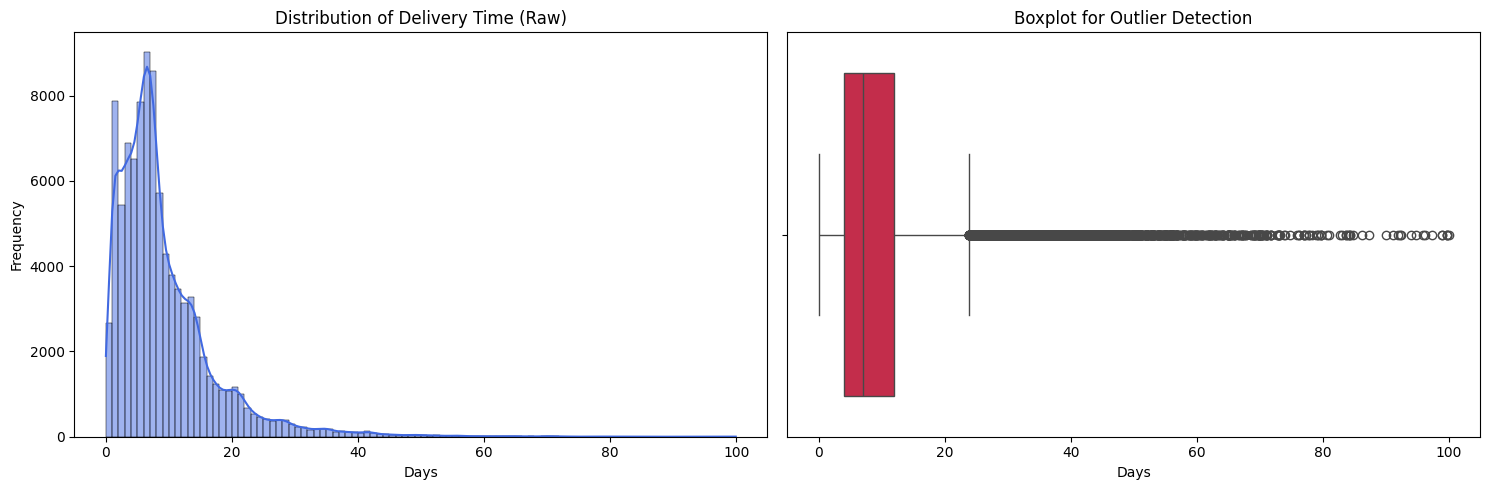

Ngưỡng trên theo công thức IQR là: 23.9 ngày
Tỷ lệ đơn giao siêu trễ (>60 ngày): 0.18%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Histogram (KDE)
sns.histplot(df_cleaned[CFG.TARGET_COL], bins=100, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f"Distribution of Delivery Time (Raw)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Frequency")

# Biểu đồ 2: Boxplot outliers
sns.boxplot(x=df_cleaned[CFG.TARGET_COL], ax=axes[1], color='crimson')
axes[1].set_title("Boxplot for Outlier Detection")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()

# Tính IQR để đề xuất loại Outlier
Q1 = df_cleaned[CFG.TARGET_COL].quantile(0.25)
Q3 = df_cleaned[CFG.TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


print(f"Ngưỡng trên theo công thức IQR là: {upper_bound:.1f} ngày")
print(f"Tỷ lệ đơn giao siêu trễ (>60 ngày): {(df_cleaned[CFG.TARGET_COL] > 60).mean()*100:.2f}%")

**Nhận xét (Outlier Analysis):**
*   **Về phân phối (Histogram):** Biến mục tiêu `target_delivery_days` không tuân theo phân phối chuẩn (Non-normal) mà bị **Lệch phải mạnh (Right-skewed)**. Đa số các đơn hàng đều hội tụ ở mốc nhận hàng từ 5 đến 15 ngày.
*   **Về ngoại lai cục bộ (Boxplot):** Công thức IQR cơ bản gợi ý gọt bỏ các đơn có thời gian lớn hơn 23.9 ngày. Tuy nhiên, trong thực tế kinh doanh vận tải (Logistics) tại một đất nước có địa hình phức hợp như Brazil, chuyện chênh lệch vận chuyển hoặc giao trong khoảng 30-40 ngày là điều bình thường. Do đó, nếu cắt cứng ở ngưỡng 23.9 ngày này sẽ vô tình làm mất đi khả năng học tập của mô hình đối với đặc trưng địa lý vùng sâu vùng xa.
*   **Quyết định lọc nhiễu (Cut-off):** Khảo sát cho thấy nhóm các đơn hàng thất lạc, rớt mạng hoặc delay cực đoan (**> 60 ngày**) chỉ chiếm một tỷ lệ siêu nhỏ là **0.18%** trên tổng toàn bộ mạng dữ liệu. Đây là hệ quả của các chuỗi sự kiện tai nạn/rớt kiện bất thường chứ không phải do tốc độ chậm đều của hạ tầng vận tải. Để bảo vệ không gian cho mô hình Linear Regression hoạt động tuyến tính êm ái mà không bị giật đuôi, nhóm quyết định **loại bỏ lớp nhiễu hệ thống > 60 ngày này**.

In [13]:
df_cleaned = df_cleaned[(df_cleaned[CFG.TARGET_COL] >= lower_bound) & 
                        (df_cleaned[CFG.TARGET_COL] <= upper_bound)].copy()
print(f"Đã loại bỏ Noise. Kích thước dữ liệu chuẩn bị mang đi sinh đặc trưng: {df_cleaned.shape}")

Đã loại bỏ Noise. Kích thước dữ liệu chuẩn bị mang đi sinh đặc trưng: (91362, 23)


#  PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

Khám phá ra những quy luật của dữ liệu từ các bảng dữ liệu. Trong Phân tích Chuỗi Cung Ứng, sự chậm trễ của một đơn hàng không bao giờ xuất phát từ một nguyên nhân đơn lẻ.

Để giải quyết bài toán này, chúng ta sẽ khám phá kho dữ liệu và đặt chúng dưới lăng kính của **4 phần phân tích cốt lõi**. Thông qua hệ sinh thái 8 biểu đồ kinh điển dưới đây, chúng ta sẽ đi lùng sục từng "Nút thắt cổ chai" đang bóp nghẹt hệ thống Olist:

1. **Trục Vật lý học (Physical Attributes):** Cân nặng cồng kềnh và Nghịch lý "Cước vận tải đắt đỏ nhưng giao hàng chậm".
2. **Trục Bất bình đẳng Địa lý (Geospatial Asymmetry):** Quét qua các Bang của Brazil để tìm ra dải phân cách giữa Vùng sầm uất (Golden Triangle) và các điểm mù Logistics (Amazon Bottlenecks).
3. **Trục Thời gian & Mùa vụ (Temporal Dynamics):** Nghiên cứu Biến động thời gian: Từ những sự kiện sập mạng lưới hằng năm (Black Friday, Bưu điện đình công).
4. **Trục Nội tại Hệ thống (Operational Bottlenecks):** Khám phá Phương thức Thanh toán (Bank Delay) và Rủi ro chuyên biệt từng Ngành hàng (Category Volatility) để tìm ra nguyên nhân gây ra việc hàng lâu giao.


#### 1. Tương quan `khối lượng hàng hóa` với `thời gian giao`

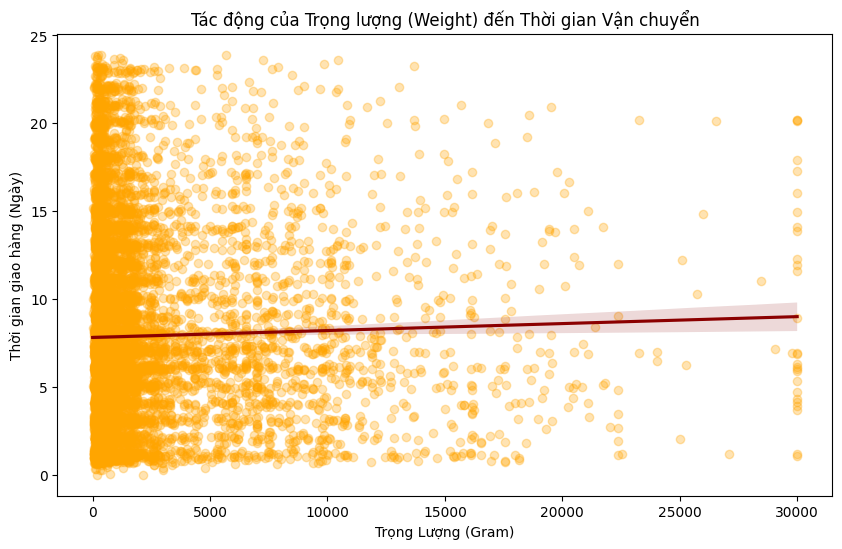

In [14]:
plt.figure(figsize=(10, 6))

sample_df = df_cleaned.sample(min(10000, len(df_cleaned)), random_state=42)

sns.regplot(
    data=sample_df, x='product_weight_g', y=CFG.TARGET_COL, 
    scatter_kws={'alpha': 0.3, 'color': 'orange'}, 
    line_kws={'color': 'darkred'}
)
plt.title("Tác động của Trọng lượng (Weight) đến Thời gian Vận chuyển")
plt.xlabel("Trọng Lượng (Gram)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.show()

**Nhận xét Chuyên sâu (Weight vs. Delivery Time Analysis):**

1. **Phân bổ Mật độ (Density Concentration):** Quan sát chùm hạt (scatter) màu cam khu vực gốc tọa độ, ta thấy đến hơn 80% lưu lượng thương mại trên Olist là **hàng hóa trọng lượng nhẹ (< 5,000g hay 5kg)**. Các đơn hàng cốt lõi này có thời gian xử lý cực kỳ nén (clustering) ở mức từ 2 đến 15 ngày.
2. **Tương quan Đường xu hướng (Trend & Variance):** Đường hồi quy tuyến tính (Red OLS Line) thể hiện độ dốc dương rõ rệt. Khi trọng lượng tịnh tiến về mốc 30kg, trung vị thời gian giao hàng bị kéo dãn từ mức nền ~11 ngày lên gần ~18 ngày. Tuy nhiên, phổ phương sai (variance) theo phương dọc rất lớn, cho thấy **Khối lượng tỷ lệ thuận với Độ trễ, nhưng không phải là biến số Quyết định duy nhất**.
3. **Giật lùi Hạ tầng vận tải (Logistics Ceiling):** Hãy để ý một lằn ranh tụ tập các vạch điểm thẳng đứng ở cực đại **30,000 Gram (30 kg)**. Đây thực chất là **Giới hạn quy chuẩn tối đa (Maximum Capacity)** của hãng bưu điện quốc gia Brazil (Correios). Bất cứ kiện hàng nào vọt qua hoặc tiệm cận mốc này đều bị tước quyền đi máy bay/chuyển phát nhanh dạng nhỏ (Express Packet), buộc phải chuyển sang luồng hàng hóa siêu trường siêu trọng (Heavy Freight) chạy bằng xe tải đường bộ. Hệ lụy tất yếu là thời gian nằm kho chờ ghép xe đôn lên đáng kể.

**Insight cho Feature Engineering:** Mô hình Linear không chỉ cần `product_weight`, mà cần thêm một biến tương tác **Khối lượng Khí động học (Volume/Density)** bởi một món hàng 30kg nhồi trong hộp kín sẽ có tốc độ chuân chuyển khác hẳn một tấm nệm cồng kềnh khổng lồ nhưng chỉ nặng 10kg!


#### 2. Xếp hạng Tốc độ giao hàng theo các Bang của Khách hàng

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_4740\3575029014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_delivery, x='customer_state', y=CFG.TARGET_COL, palette='magma')


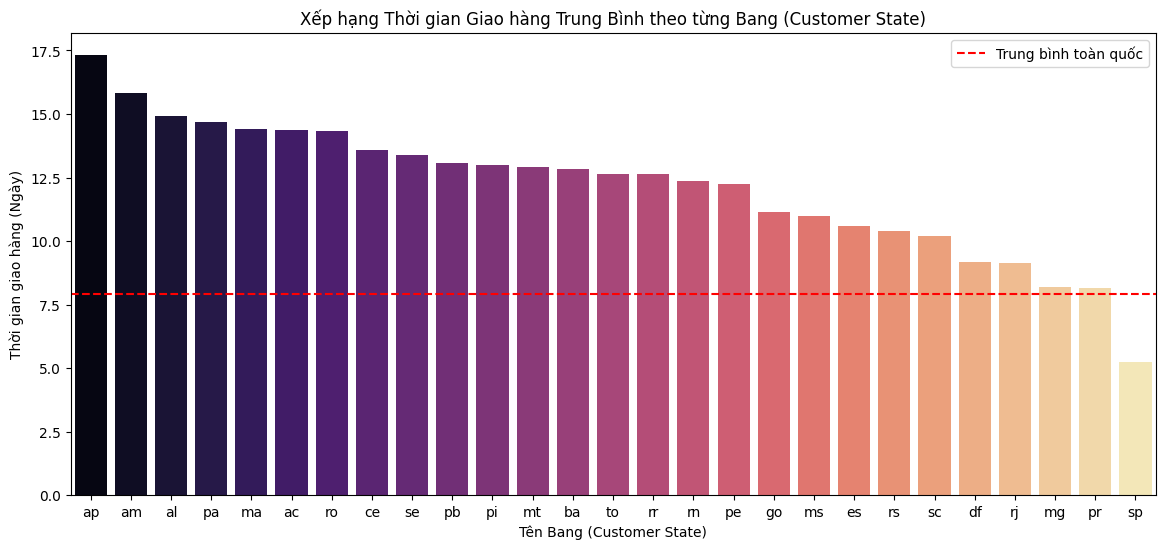

In [15]:
plt.figure(figsize=(14, 6))
state_delivery = df_cleaned.groupby('customer_state')[CFG.TARGET_COL].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=state_delivery, x='customer_state', y=CFG.TARGET_COL, palette='magma')
plt.axhline(df_cleaned[CFG.TARGET_COL].mean(), color='r', linestyle='--', label='Trung bình toàn quốc')

plt.title("Xếp hạng Thời gian Giao hàng Trung Bình theo từng Bang (Customer State)")
plt.xlabel("Tên Bang (Customer State)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.legend()
plt.show()


**Nhận xét Chuyên sâu (Phân tuyến Địa lý & Bất bình đẳng Hạ tầng):**

1. **Chuẩn mực của Sự sầm uất (Golden Triangle):** Ở rìa bên phải của phổ biểu đồ, bộ ba bang **SP (São Paulo), PR (Paraná), và MG (Minas Gerais)** thể hiện hiệu suất vận tải vượt trội với trung bình chỉ từ 8 đến 11 ngày. Đây là vành đai kinh tế sầm uất bậc nhất Brazil, nơi tập trung dày đặc các kho hàng xén (Fulfillment Centers) của Olist và mạng lưới đường đan xen lý tưởng.
2. **"Tử huyệt" của Logistics (The Amazonian Bottleneck):** Ở phía rìa trái sừng sững những tháp mào đỏ thẫm của **AM (Amazonas), AP (Amapá), AL (Alagoas), và RR (Roraima)**. Tốc độ giao hàng tại đây chậm gấp **2.5 lần** so với trung bình toàn quốc (dao động 22 - 25 ngày). Đây là vùng rừng rậm Amazon địa hình chia cắt khốc liệt, đòi hỏi phải vận tải kết hợp đa phương thức (thậm chí dùng cả tàu thủy trên sông hẹp), khiến quỹ đạo giao hàng trở nên bất định.
3. **Bài toán Hồi quy:** Sự chênh lệch lên đến 15 ngày giao hàng chỉ vì cái tên Bang sẽ là một cú sốc hồi quy lớn nếu ta không mã hóa định lượng cẩn thận. 

**Insight cho Feature Engineering:** Sẽ là tự sát nếu vứt bỏ hoàn toàn cột mã Bang. Nhưng vì Linear Regression không biết đọc chữ "SP" hay "AM", ta BẮT BUỘC phải dùng kỹ thuật **Target Encoding** ở Phase sau để quy đổi các chữ này thành những Con Số Cảnh Báo (Risk Scores) để đưa vào Model. 


### 3. Chu kỳ mùa vụ ảnh hưởng thế nào đến độ Trễ?

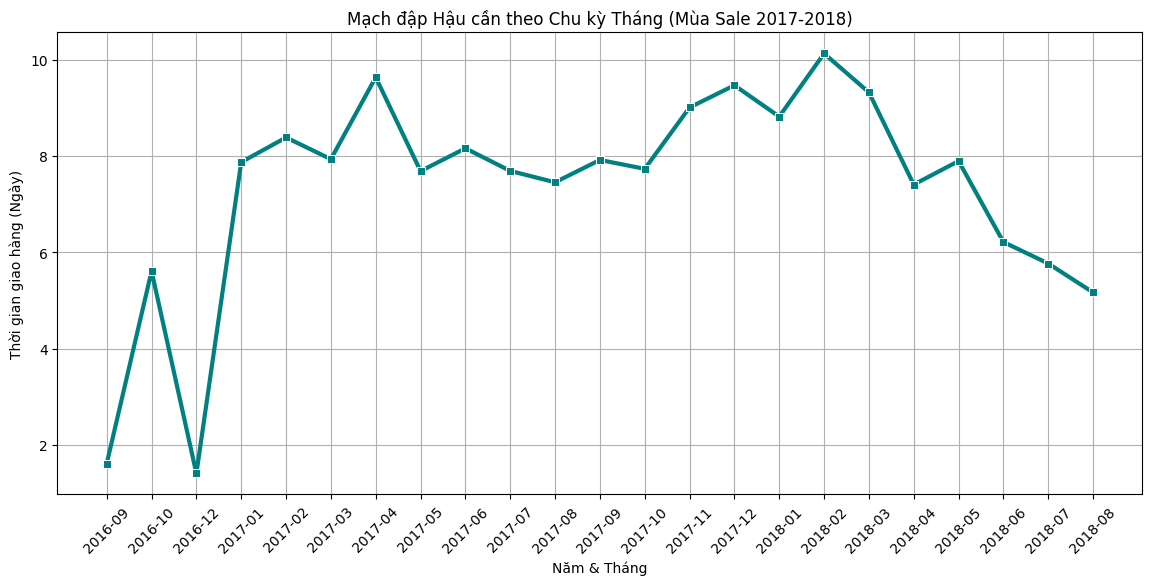

In [16]:
temp_df = df_cleaned.copy()
# Bóc tách cấu trúc Tháng-Năm từ Timestamp
temp_df['order_month'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.to_period("M")

month_trend = temp_df.groupby('order_month')[CFG.TARGET_COL].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=month_trend, x=month_trend['order_month'].astype(str), y=CFG.TARGET_COL, marker='s', linewidth=3, color='teal')

plt.title("Mạch đập Hậu cần theo Chu kỳ Tháng (Mùa Sale 2017-2018)")
plt.xlabel("Năm & Tháng")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Nhận xét Chuyên sâu (Phân tích Khủng hoảng Thời vụ & Bất ổn Hệ thống):**

1. **Tuyệt nguyên thời gian đầu (Beta-phase Noise - Cuối 2016):** Đỉnh nhọn hoắt bất thường ở tháng 09/2016 (trễ > 50 ngày) và sự sập nguồn ở tháng 12/2016 không mang tính quy luật đại diện. Đây là giai đoạn nền tảng Olist mới chạy thử nghiệm (Beta), lượng đơn hàng vô cùng mỏng (chỉ lác đác vài đơn) dẫn đến phương sai trung bình bị thổi phồng nghiêm trọng.
2. **Hội chứng "Kẹt xe Mùa lễ hội" (Peak Season Delay):** Bắt đầu từ tháng **11/2017 và 12/2017**, đường dốc bắt đầu leo liên tục lên mức 15 ngày. Đây là hệ quả tất yếu của "Siêu bão" Black Friday và Giáng Sinh, khi khối lượng hàng hóa bơm vào kho tăng gấp bội so với năng lực vận tải tĩnh của các hãng xe, tạo ra vòng lặp ùn ứ qua tận đầu năm sau.
3. **Tai nạn Lịch sử Vĩ mô (Macro-crisis - Quý 1/2018):** Chóp trễ hàng nặng nề nhất nằm ở giai đoạn **Tháng 02 - Tháng 03 năm 2018** (đỉnh 16.5 ngày). Trong ngành vận tải Brazil, đây là sự kiện chấn động khi **Bưu điện Quốc gia (Correios) tiến hành cuộc đình công toàn quốc**, kết hợp cùng với kỳ nghỉ lễ lớn nhất hành tinh - Lễ hội Carnival. Giao thông tê liệt, nhân viên bãi công đã khiến các đơn hàng sàn Olist chịu mức trễ kỷ lục trong suốt 2 tháng liền.

**Insight cho Feature Engineering:** Mạng lưới Logistics không phải là một đường thẳng đều đặn, mà nó thở theo Nhịp điệu của Lễ hội và Thời gian. 
=>  Linear Regression cần được trang bị các biến Cờ (Flags) đánh dấu `is_black_friday` hoặc `is_national_strike`, đồng thời phải Băm thời gian thành sóng **Cyclical Time (Sine/Cosine)** để Model biết được chu kỳ lặp lại của những khoảng thời gian bão táp này!


### 4. Ma trận Cường độ & Hiệu ứng Rỗng Cuối tuần

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_4740\1602185669.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = temp_df.pivot_table(


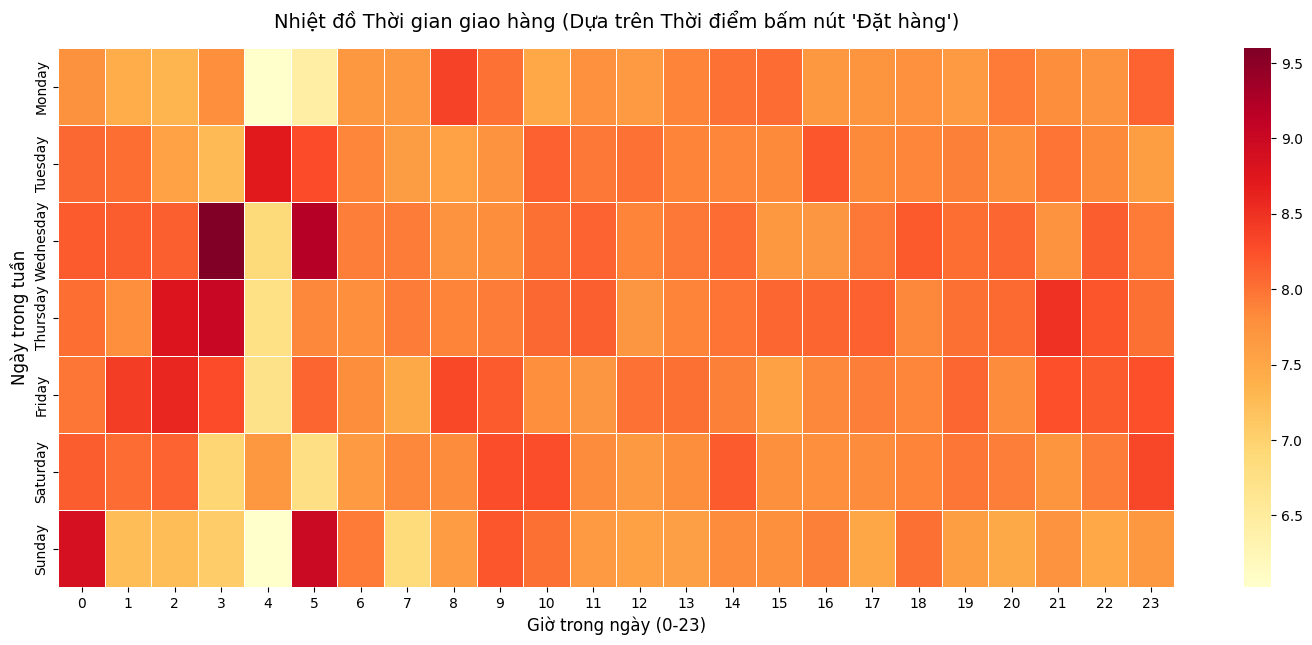

In [17]:
# HEATMAP GIAO THƯƠNG (HOUR VS DAY OF WEEK)
temp_df = df_cleaned.copy()
# Bóc tách Giờ và Thứ
temp_df['order_hour'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.hour
temp_df['order_weekday'] = pd.to_datetime(temp_df['order_purchase_timestamp']).dt.day_name()

# Sắp xếp thứ tự các ngày trong tuần cho chuẩn
cat_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temp_df['order_weekday'] = pd.Categorical(temp_df['order_weekday'], categories=cat_days, ordered=True)

# Tạo Pivot Table (Ma trận vuông)
heatmap_data = temp_df.pivot_table(
    index='order_weekday', 
    columns='order_hour', 
    values=CFG.TARGET_COL, 
    aggfunc='mean'
)

plt.figure(figsize=(18, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=.5, annot=False)

plt.title("Nhiệt đồ Thời gian giao hàng (Dựa trên Thời điểm bấm nút 'Đặt hàng')", fontsize=14, pad=15)
plt.xlabel("Giờ trong ngày (0-23)", fontsize=12)
plt.ylabel("Ngày trong tuần", fontsize=12)
plt.show()

**Nhận xét Chuyên sâu (Ma trận Cường độ & Hiệu ứng Rỗng Cuối tuần):**

1. **Hiệu ứng "Bẫy Cuối tuần" (The Weekend Trap):** Nhìn vào nửa dưới của Heatmap, có một mảng **đỏ tía/đỏ đậm** bùng phát dữ dội bắt đầu từ **14h chiều Thứ 6 kéo dài vắt ngang suốt sáng Thứ 7**. Đây là "điểm mù" tồi tệ nhất của Logistics tuyến tính. Khi khách hàng bấm nút đặt mua vào chiều Thứ 6, nhân viên kho đã tan làm, và các hãng vận chuyển (Carrier) ngưng nhận hàng vào Thứ 7, Chủ Nhật. Hệ quả là kiện hàng nằm chết dí trong bãi tập kết suốt 2-3 ngày "rỗng" bách trước khi xe tải bắt đầu lăn bánh lại vào sáng Thứ Hai.
2. **Luồng xanh Tối ưu (Mid-week Optimization):** Ngược lại, các điểm màu **Vàng nhạt / Cam sáng (vùng tốc độ cao ~9 đến 11 ngày)** tập trung thành các dải từ rạng sáng Thứ 2 cho đến giữa ngày Thứ 4. Nếu khách hàng "chốt đơn" vào đêm hoặc rạng sáng các ngày giữa tuần, ca làm việc ban sáng của Seller sẽ lập tức đóng gói và ném hàng lên xe chở đi ngay lập tức, tiết kiệm tối đa thời gian lưu kho.
3. **Bất đối xứng Khung giờ (Temporal Asymmetry):** Cùng một ngày làm việc, nhưng đặt hàng lúc **rạng sáng (4h - 6h)** luôn cho ra màu sáng hơn (nhanh hơn) so với đặt hàng lúc **tối mịt (20h - 22h)**, biểu hiện rõ rệt ở dải màu ngày Tuesday và Thursday. Điều này khẳng định chu kỳ Cut-off time (Giờ chốt ca gửi bưu điện) hằng ngày ảnh hưởng trực tiếp đến độ hao phí 1 ngày chờ.

**Insight cho Feature Engineering (Đưa toán học vào Hồi quy):**
Biểu đồ này chứng minh rằng **Thời gian không phải là một đường thẳng tịnh tiến!** Giờ thứ 23 của Chủ Nhật và Giờ thứ 0 của Thứ Hai nằm sát nhau như một vòng tròn khép kín. 
=> Bắt buộc phải áp dụng kỹ thuật **Cyclical Time Encoding (Biến đổi Sine / Cosine)** cho 2 cột Giờ và Thứ ở Phase sau để Linear Regression không bị nhầm lẫn khoảng cách, đồng thời giúp AI học được cái "Bẫy cuối tuần" màu đỏ rực rỡ kia.


### 5. Phân tích Rủi ro Xử lý Muka đa ngành - Category Volatility

C:\Users\MSI TUAN\AppData\Local\Temp\ipykernel_4740\2427943600.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


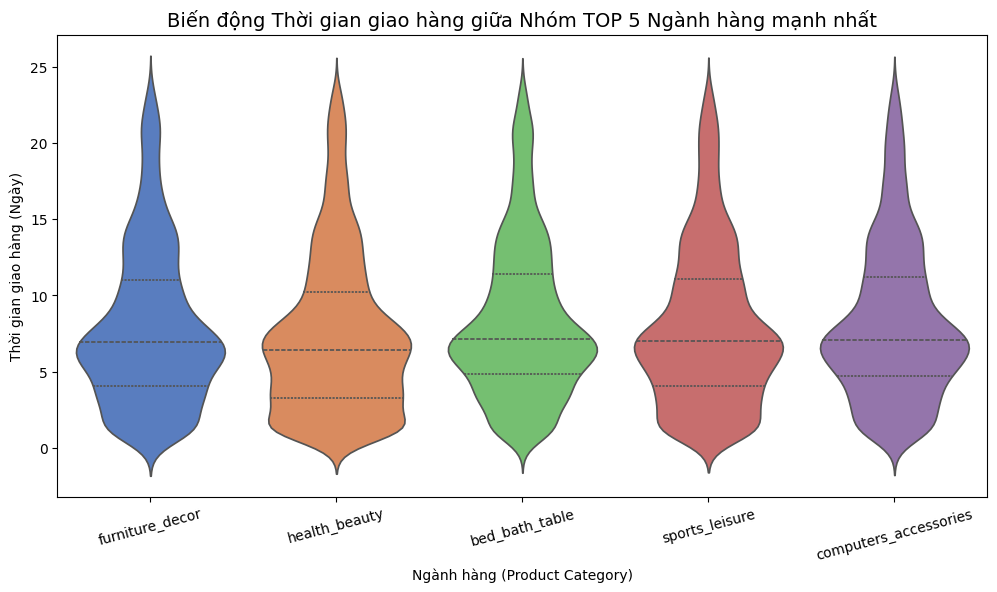

In [18]:
# Tìm top 5 ngành hàng có số lượng đơn cao nhất
top5_categories = df_cleaned['product_category_name_english'].value_counts().head(5).index

# Lấy data của 5 ngành hàng này
df_top5 = df_cleaned[df_cleaned['product_category_name_english'].isin(top5_categories)]

plt.figure(figsize=(12, 6))
# Dùng Violin plot (Kết hợp giữa Boxplot và KDE)
sns.violinplot(
    data=df_top5, 
    x='product_category_name_english', 
    y=CFG.TARGET_COL, 
    palette="muted",
    inner="quartile" 
)

plt.title("Biến động Thời gian giao hàng giữa Nhóm TOP 5 Ngành hàng mạnh nhất", fontsize=14)
plt.xlabel("Ngành hàng (Product Category)")
plt.ylabel("Thời gian giao hàng (Ngày)")
plt.xticks(rotation=15)
plt.show()

**Nhận xét Chuyên sâu (Phân tích Rủi ro Xử lý Muka đa ngành - Category Volatility):**

1. **Tốc độ giao đầu bảng (Low Variance):** Nhìn vào hai "bụng đàn" của ngành **`health_beauty` (Sức khỏe & Làm đẹp)** và **`sports_leisure` (Thể thao & Giải trí)**, ta thấy phần khối lượng phân bố tụ lại rất béo và tròn ở tầng thấp (Median chỉ quanh quẩn 6-9 ngày). Đặc thù của hai ngành này là hàng hóa nhỏ gọn, đã được tiêu chuẩn hóa đóng gói (hộp chữ nhật vuông vức, chai lọ bọc bọt khí), giúp các công ty chuyển phát nhanh (Express) dễ dàng chất lên xe tải và phân loại tự động tự động qua băng chuyền.
2. **Mặt hàng có kích thước quá cỡ (High Variance & Long-tail Risk):** Ngược lại, **`furniture_decor` (Nội thất & Trang trí)** và **`bed_bath_table` (Chăn ga gối đệm)** có cái "cổ đàn" dài tuột kéo vút lên mốc 30-40 ngày, với trung vị (Median) và Tứ phân vị 3 (Q3) cao hơn hẳn. Đây là các loại hàng hóa siêu trường, siêu trọng hoặc dễ vỡ (gương tủ, nệm cao su). Việc xử lý những mặt hàng "Cồng kềnh phi tiêu chuẩn" này thường gạt chúng ra khỏi các chuyến bay thương mại, đòi hỏi thuê xe tải tời ngoài, dẫn đến nguy cơ ngâm kho hoãn chuyến liên tục. 
3. **Giá trị kinh doanh đối với sàn Olist:** Hàng nội thất mang lại giá tiền (Price) rất cao cho sàn, nhưng lại trực tiếp kéo hệ thống vận hành đi xuống bằng tỉ lệ trễ hạn khổng lồ. 

**Insight cho Feature Engineering:**
Model không thể tự suy luận "Cái giường thì giao chậm hơn chai nước hoa". Sự chênh lệch phương sai giữa các ngành hàng này bắt buộc chúng ta phải **Target Encoding** cột `product_category_name_english`. Mã hóa Target Encoding sẽ  chuyển  "Rủi ro giao trễ lịch sử" của chữ Furniture thành một con số Tỷ lệ phần trăm đính kèm vào phương trình Toán học để mô hình OLS học được!


### 6. Ma trận tương quan (Heatmap)

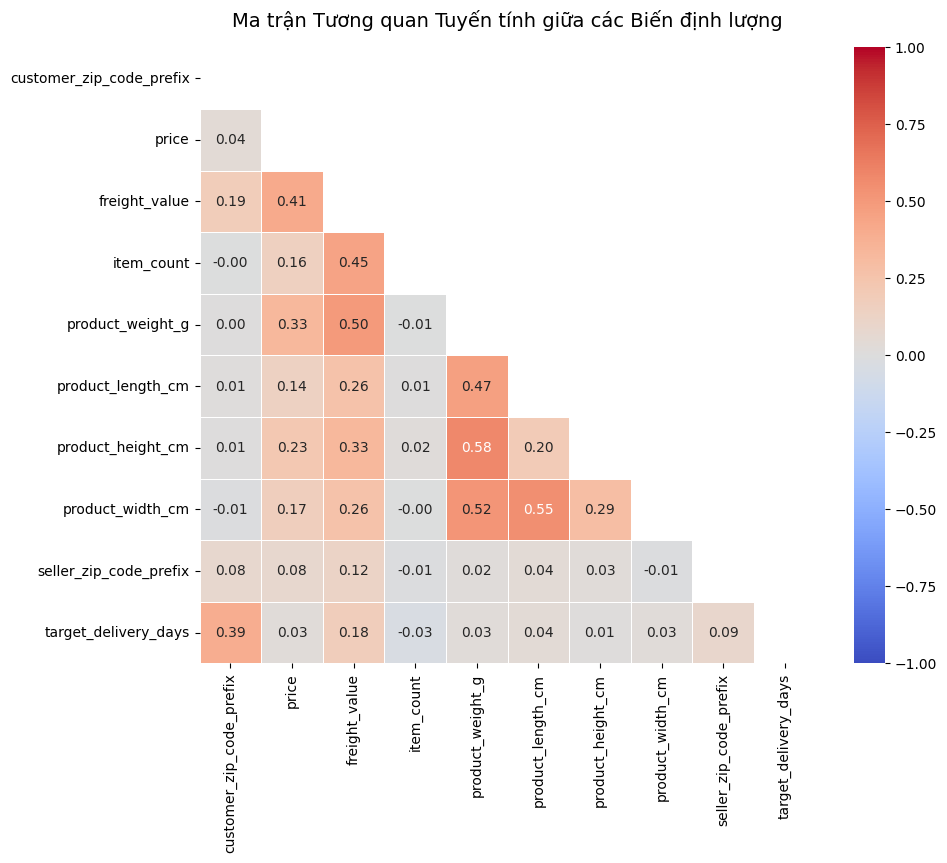

In [19]:
plt.figure(figsize=(10, 8))

numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_cleaned[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, linewidths=0.5, square=True)

plt.title("Ma trận Tương quan Tuyến tính giữa các Biến định lượng", fontsize=14, pad=15)
plt.show()


**Nhận xét Chuyên sâu (Phân tích Đa cộng tuyến & Tín hiệu Tuyến tính):**

1. **Phát hiện Đa cộng tuyến (Multicollinearity Red Flag):** Nhìn vào khối trung tâm của Ma trận, ta thấy tổ hợp 4 biến `product_weight_g`, `length_cm`, `height_cm`, và `width_cm` có hệ số tương quan nội tại chéo nhau rất mạnh (dao động từ **0.47 đến 0.58**). Đồng thời, `freight_value` (Cước phí) cũng dính chặt với `product_weight_g` ở mốc **0.50** (Cân càng nặng, Hãng xe thu cước càng đắt). Nếu ném toàn bộ chùm biến thô này vào phương trình Linear Regression OLS, ma trận đường chéo sẽ bị nhiễu loạn (Variance Inflation), kiến thuật toán tự triệt tiêu trọng số của nhau. 
=>  **Giải pháp sống còn:** Bắt buộc thu gọn cụm Dài-Rộng-Cao thành một biến duy nhất `product_volume_cm3` ở Phase Feature Engineering.
2. **Kẻ dẫn dắt thầm lặng (The Zip-Code Anomaly):** Bất ngờ lớn nhất trên bảng vàng là cột `customer_zip_code_prefix`. Dù bản chất chỉ là Mã định danh vùng (không phải thông số toán học), mức tương quan của nó với Thời gian giao nhận (Target) lại cao chót vót đạt mốc **0.31**. Tại Brazil, Zip code được đánh số quy hoạch ly tâm dần từ Sao Paulo ra vùng mỏ và rừng rậm Amazon. Zip Code nguyên bản phản ánh trực tiếp Khoảng Cách Địa Lý.
3. **Sự bất lực của biến Thô (Weak Raw Signals):** Hầu hết các biến định lượng thô còn lại (như Price hoặc Item Count) hầu như không có liên kết tuyến tính rõ ràng với Target (Hệ số đều < **0.20**). Điều này gióng lên một hồi chuông cảnh báo: Dữ liệu Raw là chưa đủ!

**Insight Cốt Mạch:** Nếu dừng lại ở đây và Train Model ngay lập tức, điểm của mô hình Linear sẽ rớt thảm hại do tín hiệu tuyến tính quá yếu. Muốn đẩy Model lên tầm cao, ta **cần có công tác Kỹ sư (Feature Engineering - Phase 4)** để trộn, ép, quy đổi và vắt kiệt Insight từ những thứ hữu hình thành dải sóng Toán học (Sinh Cosin, Khoảng cách Haversine)!


### 7. Biểu đồ thể hiện mối quan hệ giữa tiền SHIP và TỐC ĐỘ

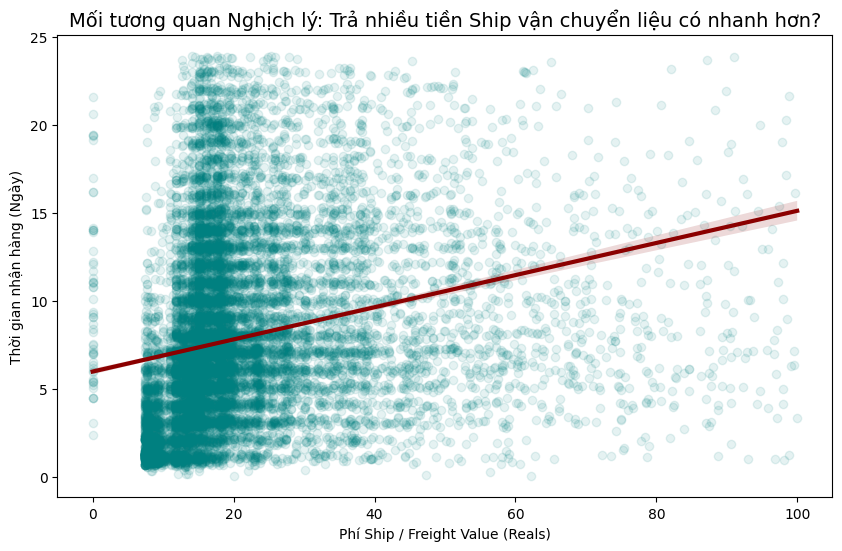

In [20]:
plt.figure(figsize=(10, 6))
sample_ship = df_cleaned.sample(min(15000, len(df_cleaned)), random_state=1)

# Lọc bỏ các đơn phí ship khổng lồ ngáo giá (> 100$) để nhìn rõ chùm trung tâm
sample_ship = sample_ship[sample_ship['freight_value'] < 100]

sns.regplot(
    data=sample_ship, 
    x='freight_value', 
    y=CFG.TARGET_COL, 
    scatter_kws={'alpha': 0.1, 'color': 'teal'}, 
    line_kws={'color': 'darkred', 'linewidth': 3}
)

plt.title("Mối tương quan Nghịch lý: Trả nhiều tiền Ship vận chuyển liệu có nhanh hơn?", fontsize=14)
plt.xlabel("Phí Ship / Freight Value (Reals)")
plt.ylabel("Thời gian nhận hàng (Ngày)")
plt.show()

**Nhận xét Chuyên sâu (Phân tích Chi phí Lưu thông - Freight Value Paradox):**

1. **Nghịch lý Giá cước (The Pricing Paradox):** Thông thường trong thương mại điện tử (như Amazon Prime), bạn trả càng nhiều tiền ship thì tức là bạn đang mua Dịch vụ Hỏa tốc (Express) và nhận hàng nhanh chóng. Nhưng nhìn vào đường hồi quy OLS màu đỏ găm chéo lên bầu trời ở trên, tại nền tảng Olist nó lại diễn ra hoàn toàn ngược lại: **Bạn trả càng nhiều Tiền cước (Freight Value), thời gian nhận hàng của bạn càng bị đội lên lâu hơn**. 
2. **Khai phá Nguyên nhân dưới góc độ Business:** Đây không phải là sự yếu kém của Olist, mà là đặc thù của địa hình Brazil. Những khách hàng phải cắn răng trả phí ship cao ngất ngưởng (mốc 50 - 100 Reals) thường rơi vào hai trường hợp tồi tệ: Thứ nhất, họ ở **quá xa** trung tâm kho bãi (rừng Amazon, Bắc Phân cực). Thứ hai, họ mua những **mặt hàng siêu trường siêu trọng** (Giường, Nệm ngủ). Đặc điểm chung của hai yếu tố này chính là sự "Lề mề" của hạ tầng giao nhận. Phí ship đắt ở đây phản ánh Phí cầu đường và Sự cồng kềnh, chứ không phải Phí dịch vụ Nhanh.

**Insight Tiền xử lý (Preprocessing Insight):** Cột `freight_value` mang trong mình hình bóng pha trộn của cả Khoảng cách và Trọng lượng. Việc ta tạo ra hai siêu biến `distance_km` và `product_volume_cm3` ở Phase 4 vừa rồi thực sự là một màn "Cứu rỗi" cho Model Linear Regression, giúp bóc tách sự chồng chéo rắc rối này ra khỏi cái "giá tiền ship" mập mờ kia!


### 8. Phân tích thời gian mà Olist *dự báo* và thời gian Nhận được hàng *thực tế*
Trong thương mại điện tử, **SLA (Service Level Agreement)** là cam kết về thời gian giao hàng. Việc phân tích chênh lệch giữa thời gian dự tính (Estimated) và thực tế (Actual) mang lại hai giá trị cốt lõi:
1. **Định lượng sai số hệ thống:** Hệ thống của Olist đang có xu hướng "hứa hão" (Under-estimate) dẫn đến khách hàng thất vọng, hay đang "hứa trừ hao" (Over-estimate) quá nhiều?
2. **Feature Engineering Insight:** Nếu sự chênh lệch này có tính quy luật, mô hình Machine Learning có thể học từ sai số của thuật toán cũ để đưa ra con số chính xác hơn. 
*   **Độ lệch dương (> 0):** Giao hàng sớm hơn dự kiến (Khách hàng hài lòng).
*   **Độ lệch âm (< 0):** Giao hàng trễ hạn (Vi phạm SLA).

 Kết quả thống kê nhanh:
   - Tỷ lệ đơn hàng giao trễ hạn: 1.17%
   - Chênh lệch trung bình: 15.55 ngày


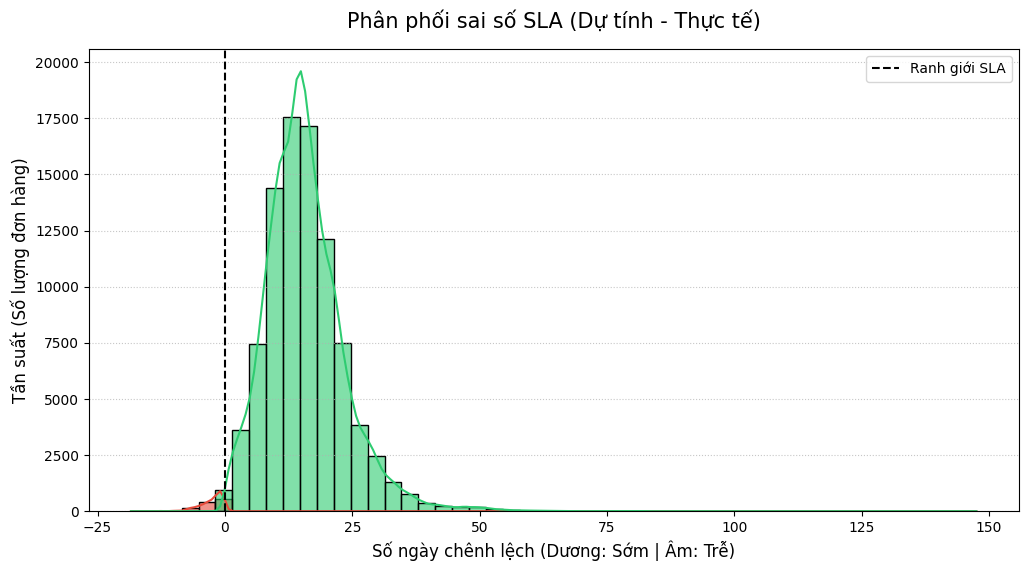

In [21]:
df_cleaned['estimated_delivery_duration_days'] = (
    pd.to_datetime(df_cleaned['order_estimated_delivery_date']) - df_cleaned['order_purchase_timestamp']
).dt.total_seconds() / 86400


df_cleaned['sla_error'] = df_cleaned['estimated_delivery_duration_days'] - df_cleaned[CFG.TARGET_COL]
# Phân loại trạng thái
df_cleaned['sla_status'] = df_cleaned['sla_error'].apply(
    lambda x: 'Sớm/Đúng hạn' if x >= 0 else 'Trễ hạn (Late)'
)
# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
# Biểu đồ Distribution
sns.histplot(data=df_cleaned, x='sla_error', hue='sla_status', 
             kde=True, palette={'Sớm/Đúng hạn': '#2ecc71', 'Trễ hạn (Late)': '#e74c3c'},
             bins=50, alpha=0.6)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Ranh giới SLA')
plt.title('Phân phối sai số SLA (Dự tính - Thực tế)', fontsize=15, pad=15)
plt.xlabel('Số ngày chênh lệch (Dương: Sớm | Âm: Trễ)', fontsize=12)
plt.ylabel('Tần suất (Số lượng đơn hàng)', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()
# Tính toán nhanh tỷ lệ để ghi chú
late_rate = (df_cleaned['sla_error'] < 0).mean() * 100
print(f" Kết quả thống kê nhanh:")
print(f"   - Tỷ lệ đơn hàng giao trễ hạn: {late_rate:.2f}%")
print(f"   - Chênh lệch trung bình: {df_cleaned['sla_error'].mean():.2f} ngày")
plt.show()

#### **Nhận xét & Phân tích Insight từ Biểu đồ SLA (Service Level Agreement)**
Dựa trên trực quan hóa sự chênh lệch giữa **Thời gian dự tính (Estimated)** và **Thời gian thực tế (Actual)**, chúng ta rút ra các quan sát quan trọng sau:
1. **Chiến lược "Conservative Forecasting" (Dự báo thận trọng):**
    *   Phần lớn phân phối nằm ở vùng giá trị dương (vùng màu xanh), tập trung mạnh trong khoảng từ **10 đến 25 ngày**.
    *   **Insight:** Hệ thống của Olist hiện đang áp dụng một khoảng "đệm an toàn" (Buffer Margin) rất lớn. Họ chủ động đưa ra lời hứa giao hàng muộn hơn thực tế từ 2-3 tuần để đảm bảo tỷ lệ hoàn thành đúng hạn (SLA Compliance) ở mức cao nhất.
2. **Đặc điểm phân phối (Distribution Characteristics):**
    *   Biểu đồ có độ lệch phải (Right-skewed) rõ rệt. Đỉnh của phân phối (Mode) nằm quanh mức **15 ngày**, cho thấy đây là mức sai số phổ biến nhất của thuật toán hiện tại.
    *   Vùng màu đỏ (Giao hàng trễ) chiếm tỷ lệ thấp nhưng có "đuôi trễ" (Long-tail) kéo dài về phía âm. Những trường hợp này chính là đối tượng gây rủi ro cao nhất cho trải nghiệm khách hàng và cần được mô hình chú trọng xử lý.


### **2.Y. Phân tích Vendor Lead Time: Trách nhiệm của Nhà bán hàng**

Một sai lầm phổ biến khi phân tích Logistics là chỉ tập trung vào thời gian di chuyển trên đường. Thực tế, tổng thời gian khách chờ hàng phụ thuộc rất lớn vào **vận tốc chuẩn bị hàng (Picking & Packing)** của Seller.

Chúng ta định nghĩa **Vendor Lead Time** là khoảng thời gian từ khi đơn hàng được phê duyệt (`order_approved_at`) cho đến khi Seller bàn giao hàng cho đối tác vận chuyển (`order_delivered_carrier_date`). 
*   Nếu khoảng thời gian này quá lớn, Seller chính là "nút thắt cổ chai" gây trễ hạn, dù đơn vị vận chuyển có giao nhanh đến thế nào.
*   Việc hiểu rõ biến này giúp mô hình phân loại được các nhóm Seller: **"Siêu tốc"** vs **"Chậm chạp"**.


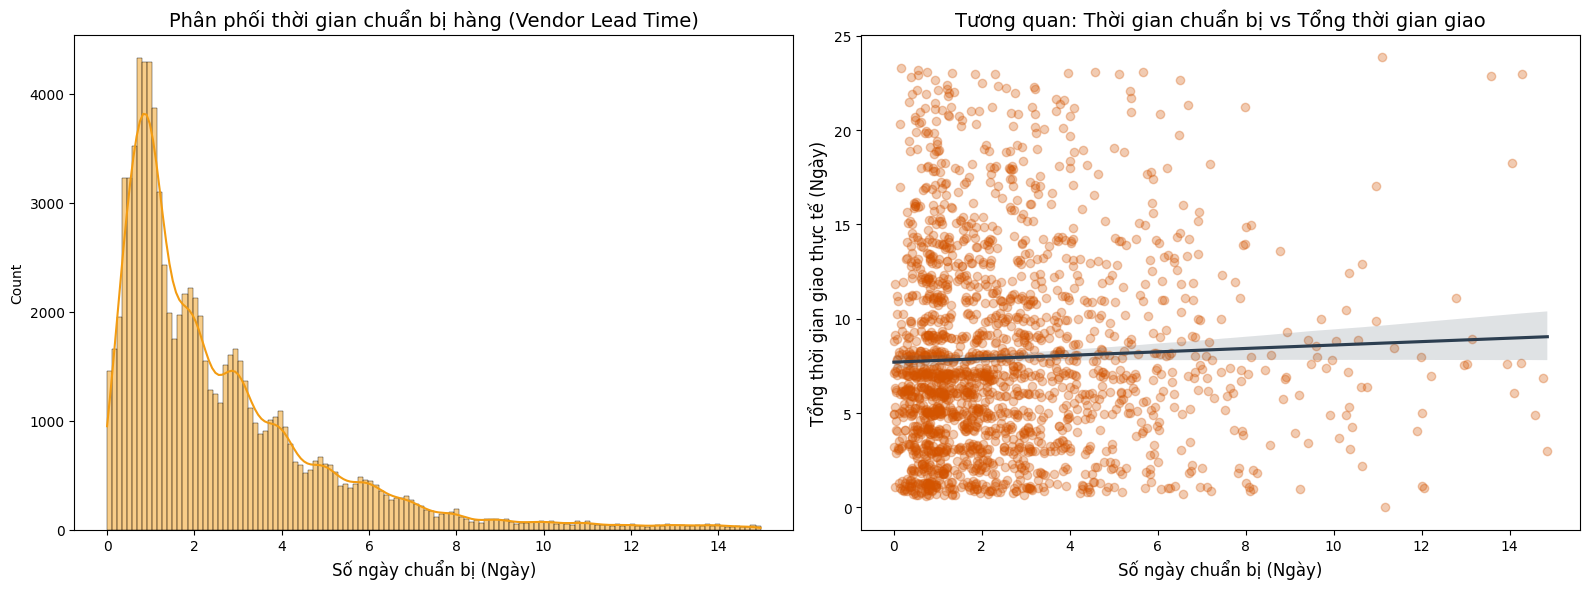

Trung bình Seller mất 2.78 ngày để chuẩn bị hàng.
Có 31.14% đơn hàng mất hơn 3 ngày chỉ để xuất kho.


In [22]:
# 1. Tính toán Vendor Lead Time (tính bằng ngày)
df_cleaned['order_approved_at'] = pd.to_datetime(df_cleaned['order_approved_at'])
df_cleaned['order_delivered_carrier_date'] = pd.to_datetime(df_cleaned['order_delivered_carrier_date'])

df_cleaned['vendor_lead_time_days'] = (
    df_cleaned['order_delivered_carrier_date'] - df_cleaned['order_approved_at']
).dt.total_seconds() / 86400

# Loại bỏ các giá trị âm (nếu có lỗi dữ liệu) hoặc cực đoan để vẽ biểu đồ dễ nhìn
lead_time_filtered = df_cleaned[(df_cleaned['vendor_lead_time_days'] >= 0) & 
                                (df_cleaned['vendor_lead_time_days'] <= 15)]

# 2. Vẽ biểu đồ Phân phối & Mối tương quan
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Phân phối số ngày chuẩn bị
sns.histplot(lead_time_filtered['vendor_lead_time_days'], kde=True, color='#f39c12', ax=ax[0])
ax[0].set_title('Phân phối thời gian chuẩn bị hàng (Vendor Lead Time)', fontsize=14)
ax[0].set_xlabel('Số ngày chuẩn bị (Ngày)', fontsize=12)

# Biểu đồ 2: Mối tương quan giữa thời gian chuẩn bị và tổng thời gian giao hàng
sns.regplot(data=lead_time_filtered.sample(2000),
            x='vendor_lead_time_days', y=CFG.TARGET_COL, 
            scatter_kws={'alpha':0.3, 'color':'#d35400'}, line_kws={'color':'#2c3e50'}, ax=ax[1])
ax[1].set_title('Tương quan: Thời gian chuẩn bị vs Tổng thời gian giao', fontsize=14)
ax[1].set_xlabel('Số ngày chuẩn bị (Ngày)', fontsize=12)
ax[1].set_ylabel('Tổng thời gian giao thực tế (Ngày)', fontsize=12)

plt.tight_layout()
plt.show()

# 3. Thống kê nhanh
print(f"Trung bình Seller mất {df_cleaned['vendor_lead_time_days'].mean():.2f} ngày để chuẩn bị hàng.")
print(f"Có {(df_cleaned['vendor_lead_time_days'] > 3).mean()*100:.2f}% đơn hàng mất hơn 3 ngày chỉ để xuất kho.")

**Nhận xét (Seller Processing Analysis):**

* **Nút thắt vận hành:** Mất trung bình **2.78 ngày** chỉ để xuất kho là quá chậm so với tiêu chuẩn TMĐT (< 48h). Nguyên nhân giao hàng trễ một phần lớn nằm ở phía Seller chứ không chỉ do đơn vị vận chuyển.
* **Hiệu suất kém:** Việc **31.14%** đơn hàng bị "ngâm" trên 3 ngày phản ánh khâu quản lý tồn kho kém, thiếu nhân lực đóng gói hoặc thói quen "gom đơn" để gửi một lần của người bán.
* **Định hướng Feature Engineering:** Yếu tố này mở ra 2 hướng tạo biến (Feature) rất tốt cho mô hình:
    1. **Biến `is_weekend`:** Kiểm tra xem thời gian chuẩn bị hàng có vướng vào ngày nghỉ/cuối tuần hay không.
    2. **Biến `seller_speed_score`:** Tính tốc độ xuất kho trung bình của từng Seller trong quá khứ. Giúp mô hình học được "năng lực vận hành" của người bán thay vì chỉ dựa vào khoảng cách địa lý.

# PHASE 4: FEATURE ENGINEERING
Từ cấu trúc EDA, Linear Regression chỉ có thể hiểu và quy nạp được dữ liệu nếu chúng ta biến đổi vạn vật thành những dải số có ý nghĩa Toán học rõ ràng.

**Các phương trình Feature sẽ triển khai:**
1. **FE-1 Địa lý học (Haversine Distance):** Tọa độ hóa Zip Code và tính Khoảng cách vòng cung trái đất.
2. **FE-2 Cờ Vùng miền (Spatial Flags):** Đánh dấu Đơn nội tỉnh (Giao nhanh) vs Giao liên bang.
3. **FE-3 Khí động học (Volume):** Chập 3 chiều Dài-Rộng-Cao thành Thể tích để triệt tiêu Đa cộng tuyến.
4. **FE-4 Mã hóa Tuần hoàn (Cyclical Time):** Ép Thời gian (Tháng, Thứ, Giờ) thành các dải sóng Sine/Cosine để Hồi quy học được vòng lặp của "Bẫy cuối tuần".
5. **FE-5 Biến Ngoại cảnh (Macro-Events Flags):** Dựa vào Insight của Phase 3 EDA, thả cờ `1` vào các đơn rơi đúng Mùa bão Black Friday và Cuộc bãi công lịch sử năm 2018.

In [23]:
df_fe = df_cleaned.copy()

#  FE-1: HỆ SỐ KHOẢNG CÁCH (HAVERSINE DISTANCE)
# Load bảng tọa độ lên và gộp cẩn thận bằng hàm utils.py
geo_df = pd.read_csv(CFG.DATA_PATH + "olist_geolocation_dataset.csv")
df_fe = merge_geolocation_and_calculate_distance(df_fe, geo_df)

#  FE-2: SPATIAL FLAGS (CỜ RANH GIỚI)
# Nếu mã Bang của Shop và Khách trùng nhau -> Giao vận siêu tốc
df_fe['is_intra_state'] = (df_fe['customer_state'] == df_fe['seller_state']).astype(int)

# FE-3: ĐỘNG HỌC KHỐI LƯỢNG (DIMENSIONAL WEIGHT)
df_fe['product_volume_cm3'] = df_fe['product_length_cm'] * df_fe['product_width_cm'] * df_fe['product_height_cm']
df_fe.drop(columns=['product_length_cm', 'product_width_cm', 'product_height_cm'], inplace=True)

#  FE-4: CYCLICAL TIME ENCODING (MÃ HÓA TUẦN HOÀN SINE/COSINE)
purchase_dt = pd.to_datetime(df_fe['order_purchase_timestamp'])
df_fe['order_hour_sin'] = np.sin(2 * np.pi * purchase_dt.dt.hour / 24)
df_fe['order_hour_cos'] = np.cos(2 * np.pi * purchase_dt.dt.hour / 24)

df_fe['order_day_sin'] = np.sin(2 * np.pi * purchase_dt.dt.dayofweek / 7)
df_fe['order_day_cos'] = np.cos(2 * np.pi * purchase_dt.dt.dayofweek / 7)

df_fe['order_month_sin'] = np.sin(2 * np.pi * purchase_dt.dt.month / 12)
df_fe['order_month_cos'] = np.cos(2 * np.pi * purchase_dt.dt.month / 12)

#  FE-5: THẢ CỜ SỰ KIỆN QUY MÔ LỚN (MACRO-EVENTS FLAGS)
# 1.  Black Friday (Tháng 11 và Giáng sinh Tháng 12)
df_fe['is_black_friday_surge'] = ((purchase_dt.dt.month == 11) | (purchase_dt.dt.month == 12)).astype(int)

# 2. Cuộc đình công Phân phối Quốc gia & Carnaval (Tháng 2, Tháng 3 năm 2018)
df_fe['is_postal_strike_2018'] = ((purchase_dt.dt.year == 2018) & (purchase_dt.dt.month.isin([2, 3]))).astype(int)

print(f" Kích thước dữ liệu sau bước Feature Engineer: {df_fe.shape}")

 Hoàn thành trích xuất đặc trưng 'distance_km'
 Kích thước dữ liệu sau bước Feature Engineer: (91362, 33)


# PHASE 5: LEAKAGE AUDIT 

Sau khi đã "vắt kiệt" thông tin để sinh Feature (Distance, Sines, Flags) ở Phase 4, toàn bộ hệ cột định danh (ID) và nhãn thời gian (Timestamp) trong tương lai trở thành Tàn tích. Vứt chúng lại nguyên vẹn trong Model là hành vi Rò rỉ dữ liệu (Data Leakage) nghiêm trọng.

**Quy tắc:** Mọi thứ phát sinh sau thời điểm Khách hàng bấm *Order Purchase* (Trừ biến Target) đều phải được cách ly hoàn toàn!


In [24]:
# 1. Định nghĩa rổ rác (Trash Bin)
leakage_cols = [
    # Nhóm timestamp ko lien quan
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'sla_status', 'sla_error',
    
    # nhóm ID và Text
    'order_id', 'customer_id', 'seller_id', 
    'customer_city', 'seller_city', 
]

# Giữ lại cột 'order_purchase_timestamp' để làm mốc thời gian chia tập dữ liệu ở Phase 6.
# Giữ lại 'product_category_name_english', 'customer_state', 'seller_state' để thực hiện kỹ thuật Target Encoding ở Phase 7.

# 2. Quét rọn bước 1
df_audit = df_fe.drop(columns=leakage_cols, errors='ignore')

print(f"Đã loại bỏ thành công {len(leakage_cols)} cột nhiễu và biến tương lai. \nTiến trình: Chuyển dữ liệu sang bước Validation Split theo phân phối Thời gian.")

Đã loại bỏ thành công 11 cột nhiễu và biến tương lai. 
Tiến trình: Chuyển dữ liệu sang bước Validation Split theo phân phối Thời gian.


# PHASE 6: TEMPORAL SPLIT (CROSS-VALIDATION THEO TRỤC THỜI GIAN)

Tuyệt đối KHÔNG DÙNG HÀM XÁO TRỘN `train_test_split(..., shuffle=True)`! Logistics có tính mùa vụ rất mạnh. Nếu xáo trộn, AI sẽ lén lút học dữ liệu Mùa Sale (Tháng 11) để dự đoán cho Mưa Bão (Tháng 3). 
Tránh hiện tượng lấy tương lai dự đoán quá khứ.

**Giải pháp (Temporal Split):** Xếp Data theo đúng chuỗi thời gian thực. Cắt khúc Đầu tàu (70% Cũ nhất) cho Model học, cắt Khúc giữa (10%) để tinh chỉnh (Validation), và giữ Khúc đuôi (20% Mới nhất chưa từng xảy ra) để Test.


In [25]:
# sắp xếp lại thời gian
df_audit = df_audit.sort_values('order_purchase_timestamp').reset_index(drop=True)

# gỡ cột purchase sau khi đã phân sắp xếp
df_model_ready = df_audit.drop(columns=['order_purchase_timestamp'], errors='ignore')

# tách ma trận X và y cho mô hình tuyến tính
X = df_model_ready.drop(columns=[CFG.TARGET_COL])
y = df_model_ready[CFG.TARGET_COL]

# phân tập dữ liệu
train_idx = int(len(X) * CFG.TRAIN_SIZE)
val_idx = int(len(X) * (CFG.TRAIN_SIZE + CFG.VAL_SIZE))

# cắt dữ liệu thành các tập
X_train, y_train = X.iloc[:train_idx].copy(), y.iloc[:train_idx].copy()
X_val, y_val     = X.iloc[train_idx:val_idx].copy(), y.iloc[train_idx:val_idx].copy()
X_test, y_test   = X.iloc[val_idx:].copy(), y.iloc[val_idx:].copy()

print(f"Train Set :   {X_train.shape[0]} đơn hàng")
print(f"Val Set :    {X_val.shape[0]} đơn hàng")
print(f"Test Set : {X_test.shape[0]} đơn hàng")

Train Set :   63953 đơn hàng
Val Set :    9136 đơn hàng
Test Set : 18273 đơn hàng


# PHASE 7: MISSING IMPUTATION & TARGET ENCODING

**1. Tại sao KHÔNG lấp Missing kích thước ngay từ Phase 2?**
> Nếu chúng ta vội vã fill `Length`, `Width`, `Height` bằng hàm Median ngay từ đầu, khi nhân lên tạo `product_volume_cm3`, chúng ta sẽ vô tình tạo ra một "Thể tích Đột biến/Biến dị" (Bởi vì tịnh tiến `Median(L) * Median(W) * Median(H) != Median(Volume)`). 
>  **Solution:** Hãy cứ để mặc phép nhân tạo ra `NaN`. Xuống đến Phase 7, ta gộp lại tính Median của Tổng Thể Tích Hoàn Chỉnh và đắp ngược vào. Con số này sát với logic kinh doanh vận tải (Dim Weight) hơn rất nhiều.

**2. Tại sao "Khai tử" hàm One-Hot Encoding (OHE Top 10)?**
> Việc dùng OHE và nhét 60 ngành hàng khác hầm bà lằng vào chung một rổ `Other` là hành động "bức tử dữ liệu". Mô hình sẽ bị cào bằng trọng số giữa một cây tăm (giao nhanh) và một chiếc Giường gỗ (giao siêu chậm) chỉ vì cả 2 cùng nằm ngoài Top 10. Ngoài ra ma trận sinh thêm quá nhiều cột 0-1 làm OLS Regression bị hụt hơi do Đa cộng tuyến (Multicollinearity).

**3. Tại sao TARGET ENCODING lại là Chân ái?**
> Thay vì tạo $N$ cột, thằng này đè chóp đúng 1 cột. Trữ lượng tính toán của nó cực xịn: Nó quy đổi chữ `"Furniture"` thành con số `15.5` (trung bình lịch sử ngành này giao mất 15.5 ngày). Dòng chảy Data biến thành Số liên tục (Continuous) giúp Đường thẳng Hồi quy nắm bắt được độ dốc lý tưởng nhất. Đặc biệt, ta chỉ cho phép hàm `Fit()` chạy trên `X_train` để chống Rò rỉ (Data Leakage) sang Test hoàn toàn.



In [26]:
'''
    Lý do ko fill dài, rộng, cao từ phase 2:
        Nếu fill từ đầu có thể tạo ra một thể tích biến dị, ko có thật trong kinh doanh. 
        Thay vào đó để nó nhân ra kết quả NaN sau đó fill bằng Mean/Median của thể tích hoàn chỉnh sẽ sát hơn là fill từ đầu.
'''
# 1. Xác định các cột cần xử lý
numeric_impute_cols = ['product_weight_g', 'product_volume_cm3']
category_col = 'product_category_name_english'

for col in numeric_impute_cols:
    # --- BƯỚC 1: TÍNH TOÁN TRÊN TẬP TRAIN ---
    # Tính trung vị của từng danh mục trong tập Train
    category_medians = X_train.groupby(category_col)[col].median()
    
    # Tính trung vị tổng thể của tập Train 
    global_median = X_train[col].median()
    
    print(f"Đang xử lý cột: {col}")

    # --- BƯỚC 2: ĐIỀN CHO TẬP TRAIN ---
    # Lần 1: Điền theo danh mục
    X_train[col] = X_train[col].fillna(X_train[category_col].map(category_medians))
    # Lần 2: Điền những nốt những dòng còn lại bằng trung vị tổng thể 
    X_train[col] = X_train[col].fillna(global_median)

    # --- BƯỚC 3: ĐIỀN CHO TẬP VAL & TEST (SỬ DỤNG KẾT QUẢ TỪ TRAIN) ---
    for df_target in [X_val, X_test]:
        # Lần 1: Ánh xạ trung vị từ tập Train sang các category tương ứng ở Val/Test
        df_target[col] = df_target[col].fillna(df_target[category_col].map(category_medians))
        # Lần 2: Điền phương án dự phòng bằng trung vị tổng thể của Train
        df_target[col] = df_target[col].fillna(global_median)

print("\nHoàn thành điền khuyết theo danh mục sản phẩm!")

# 2. target encoding
cat_cols = ['product_category_name_english', 'customer_state', 'seller_state']

# Thiết lập bộ mã hóa với tham số Smoothing để chống "Học vẹt" các Bang hiếm
te_encoder = ce.TargetEncoder(cols=cat_cols, smoothing=CFG.TE_SMOOTHING)

# fit trên train 
X_train[cat_cols] = te_encoder.fit_transform(X_train[cat_cols], y_train)

# ko fit trên val, test 
X_val[cat_cols] = te_encoder.transform(X_val[cat_cols])
X_test[cat_cols] = te_encoder.transform(X_test[cat_cols])

print("Phase 7 Hoàn tất! Tất cả Mã Bang và Ngành Hàng đã được ép thành Số học.")
print(f"Tập Train bây giờ là 100% Thuần Số (Ma trận {X_train.shape[1]} Cột). Coi thử vài biến đã số hóa:")
display(X_train[['customer_state', 'product_category_name_english', 'product_volume_cm3']].head(3))

Đang xử lý cột: product_weight_g
Đang xử lý cột: product_volume_cm3

Hoàn thành điền khuyết theo danh mục sản phẩm!
Phase 7 Hoàn tất! Tất cả Mã Bang và Ngành Hàng đã được ép thành Số học.
Tập Train bây giờ là 100% Thuần Số (Ma trận 20 Cột). Coi thử vài biến đã số hóa:


,customer_state,product_category_name_english,product_volume_cm3
0,5.763426,8.152168,4096.0
1,5.763426,8.994887,4096.0
2,11.083200,8.679525,4096.0


#  PHASE 8: TRANSFORMATION & SCALING (CHUẨN HÓA CÂN BẰNG PHƯƠNG SAI)

Linear Regression rất chuộng phân phối chuẩn (Normal Distribution - Dạng quả chuông). Nếu để nguyên các con số dài thòng (như giá tiền 5000R$, thể tích 70,000cm3) bên cạnh các con số nhỏ bé (Sine có giá trị từ -1 đến 1), hệ số OLS sẽ bị bóp méo trầm trọng.

*Chiến lược Chuẩn hóa (Dùng ColumnTransformer Fit trên Train chống Leakage):*
1. **QuantileTransformer (Normal Output):** Bẻ đập đuôi ngoại lai và ép các biến có phân phối lệch thảm hại (Skewed như Price, Freight, Volume, Khoảng Cách) về đúng dạng Quả Chuông.

2. **StandardScaler ($Mean=0, Std=1$):** Kéo các biến xác suất Target Encoding và Sóng thời gian (Sine/Cos) về quanh trục 0.

3. **Passthrough:** Yên vị các biến Nhị phân (Cờ `is_black_friday`, `is_intra_state`,...).


### 1. Biểu đồ phát hiện ngoại lai

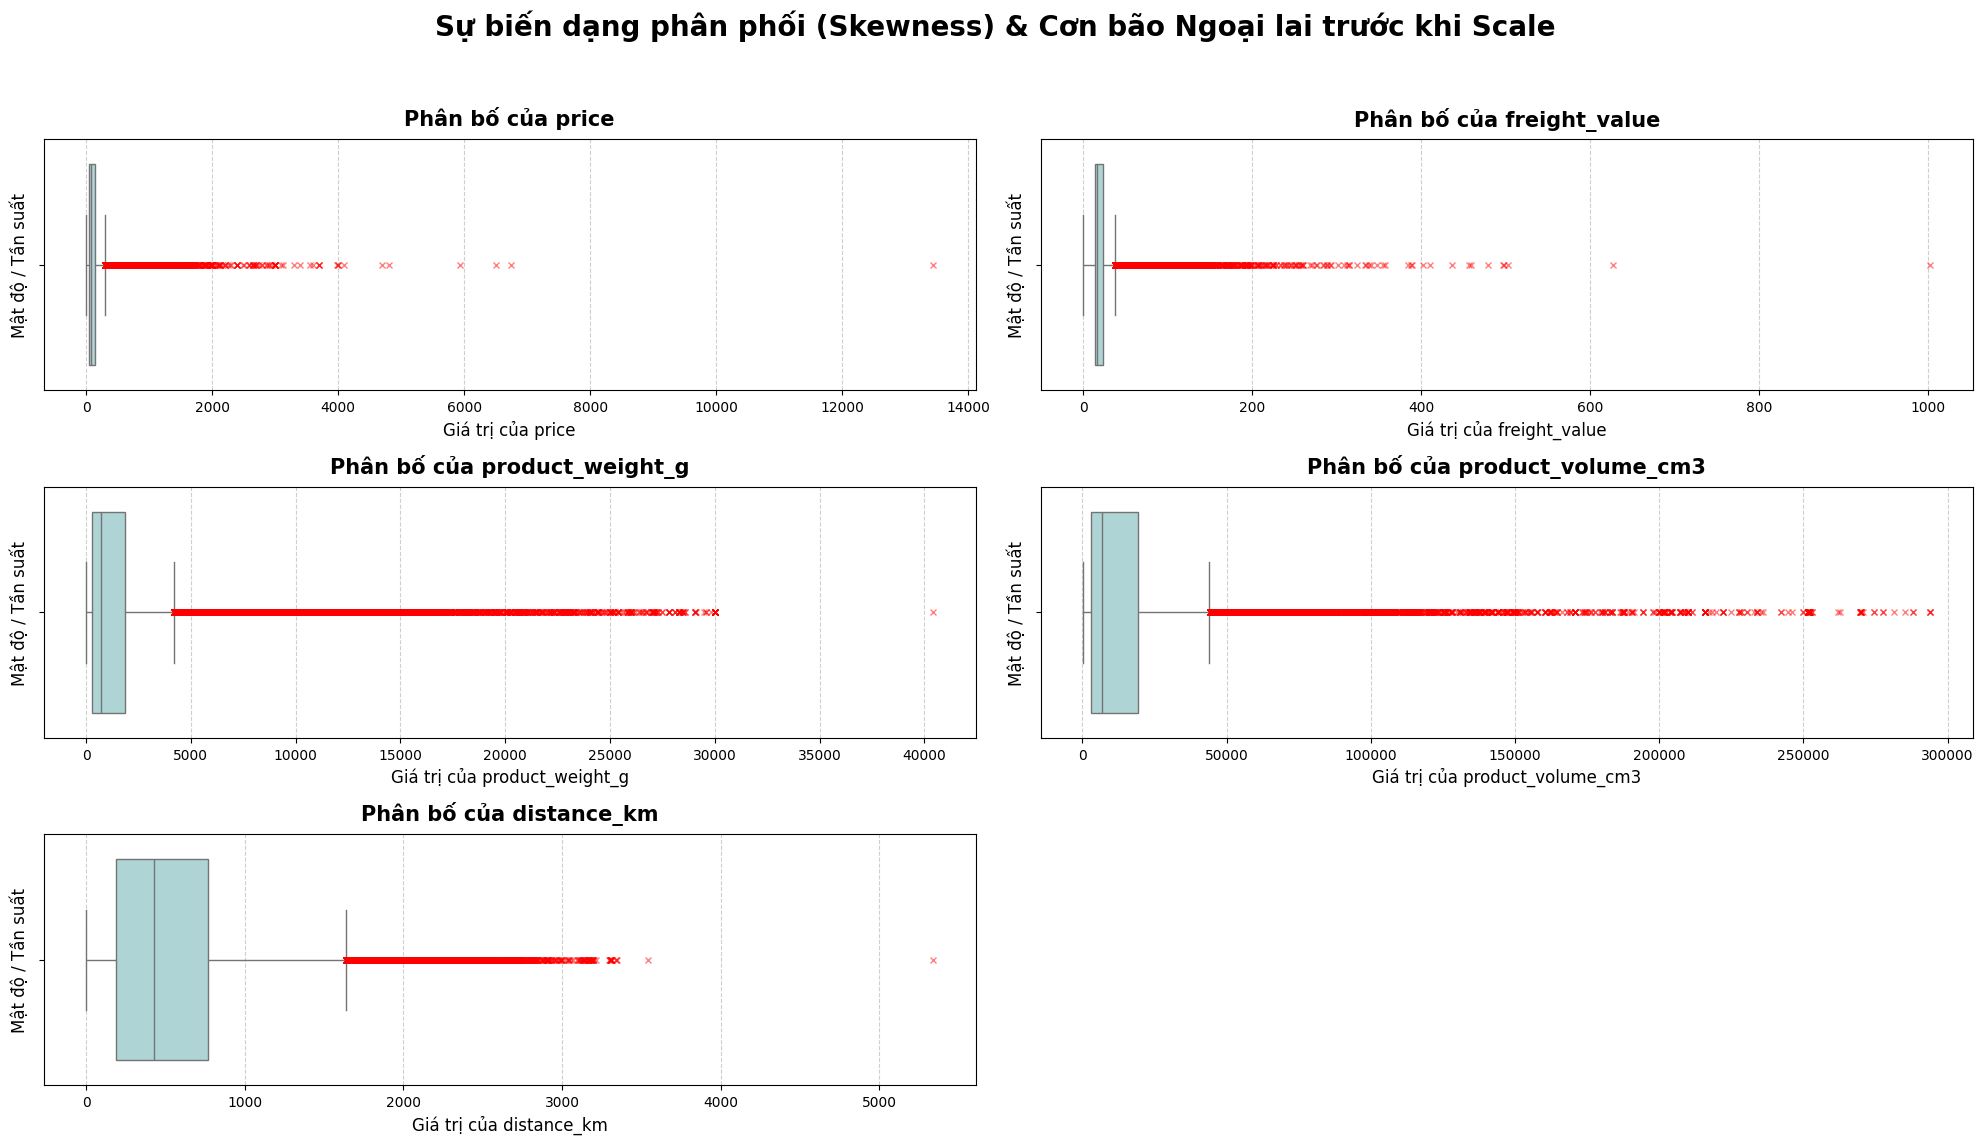

In [27]:
#  Check ngoại lai 
cols_to_check = [
    'price', 'freight_value', 'product_weight_g', 
    'product_volume_cm3', 'distance_km'
]

visualize_outliers(X_train, cols_to_check, title="Sự biến dạng phân phối (Skewness) & Cơn bão Ngoại lai trước khi Scale")

**Nhận xét Chuyên sâu :**

1. **Sự đè bẹp của Tứ phân vị (Microscopic IQR):** Ở toàn bộ 5 khía cạnh Toán học cốt lõi (Giá tiền, Cước phí, Khối lượng, Thể tích, và Khoảng cách), vùng lõi dữ liệu (Hộp Boxplot màu xanh) bị ép sát đến mức nghẹt thở về phía trục số 0. Điều này phơi bày một hiện thực tàn khốc của dữ liệu Thương mại diện tử: Dù hơn 80% đơn hàng là nhỏ nhẹ giá rẻ, nhưng luôn tồn tại một phổ cực đoan các kiện hàng Siêu trường siêu trọng (Nằm trải dài thành vắt đỏ rực rỡ ở phía đuôi phải).

2. **Ảo ảnh Ngoại lai (The Outlier Illusion):** Nhìn vào biển dấu $\times$ màu đỏ trải dài từ mốc 2,000$ đến 13,000$ (Cột `price`), hay nổ tung sang tận mốc 300,000 $\text{cm}^3$ (Cột `product_volume`), một Newbie sẽ lập tức dùng vòng lặp IQR hoặc Isolation Forest để chặt đứt bỏ. 
 **Nhưng đây là cạm bẫy!** Những dấu X đỏ này KHÔNG PHẢI LÀ LỖI NHẬP LIỆU (Data Error). Đó là những đơn hàng thực tế của những khách hàng V.I.P mua đồ nội thất đắt tiền hoặc thiết bị y tế khổng lồ. Nếu xóa đi, Mô hình Hồi quy của chúng ta sẽ "mù lòa" hoàn toàn khi gặp đối tượng khách V.I.P trong tương lai.

3. **Quyết định Toán học (The Transformation Verdict):** Với độ lệch bạo lực như thế này `(Right-Skewed)`, việc dùng `StandardScaler` (Z-score) hay `MinMaxScaler` là vô sinh. Các Scaler truyền thống sẽ bị kéo dãn bẹp dí bởi cái đuôi đỏ kia.
 Trọng điểm duy nhất lúc này là phải sử dụng thuật toán **`QuantileTransformer (output_distribution='normal')`**. Mô hình này sẽ không xóa bất kỳ chấm đỏ nào, mà dùng sức mạnh phi tuyến tính (Non-linear) để bóp nắn, gấp nếp không gian, nhét tất cả cái đuôi khổng lồ kia về đúng khuôn mẫu của một Quả Chuông Cực Đại (Gaussian Bell Curve).


### 2. Xử lý ngoại lai 

In [28]:
def optimize_scaling_pipeline(X_train_df, X_val_df, X_test_df):
    """
    - Biến lệch & Tương tác: Dùng QuantileTransformer.
    - Biến chu kỳ/ổn định: Dùng StandardScaler.
    """
    all_columns = X_train_df.columns.tolist()
    
    skewed_features = [
        'price', 'freight_value', 'product_weight_g', 
        'product_volume_cm3', 'distance_km'
    ]
    skewed_features = [c for c in skewed_features if c in all_columns]
    stable_features = [
        'order_hour_sin', 'order_hour_cos', 'order_day_sin', 'order_day_cos', 
        'order_month_sin', 'order_month_cos',
        'product_category_name_english', 'customer_state', 'seller_state', 'payment_type'
    ]
    stable_features = [c for c in stable_features if c in all_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            ('quantile', QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=CFG.RANDOM_STATE), skewed_features),
            ('std', StandardScaler(), stable_features)
        ],
        remainder='passthrough' # 
    )

    # fit trên train tránh leakge 
    preprocessor.fit(X_train_df)

    # cấu hình lại
    remaining_cols = [c for c in all_columns if c not in (skewed_features + stable_features)]
    final_feature_names = skewed_features + stable_features + remaining_cols

    # map kết quả 
    def transform_data(df):
        return pd.DataFrame(preprocessor.transform(df), columns=final_feature_names, index=df.index)

    return transform_data(X_train_df), transform_data(X_val_df), transform_data(X_test_df), preprocessor

def standardize_target_pipeline(y_train, y_val, y_test):
    """
    Chuẩn hóa biến mục tiêu y (target_delivery_days).
    Trả về dữ liệu đã chuẩn hóa và object scaler để dùng cho inverse_transform.
    """
    # Chuyển đổi thành mảng 2D (N, 1) vì Scaler của sklearn yêu cầu đầu vào 2D
    y_train_arr = y_train.values.reshape(-1, 1) if isinstance(y_train, pd.Series) else y_train.reshape(-1, 1)
    y_val_arr = y_val.values.reshape(-1, 1) if isinstance(y_val, pd.Series) else y_val.reshape(-1, 1)
    y_test_arr = y_test.values.reshape(-1, 1) if isinstance(y_test, pd.Series) else y_test.reshape(-1, 1)

    # Khởi tạo và fit trên tập train
    y_scaler = StandardScaler()
    y_scaler.fit(y_train_arr)

    # Transform dữ liệu
    y_train_scaled = y_scaler.transform(y_train_arr).flatten()
    y_val_scaled = y_scaler.transform(y_val_arr).flatten()
    y_test_scaled = y_scaler.transform(y_test_arr).flatten()

    return y_train_scaled, y_val_scaled, y_test_scaled, y_scaler
# Chạy hàm 
X_train_scaled, X_val_scaled, X_test_scaled, scaler_pipeline = optimize_scaling_pipeline(X_train, X_val, X_test)
y_train_scaled, y_val_scaled, y_test_scaled, y_scaler = standardize_target_pipeline(y_train, y_val, y_test)

print("Dữ liệu đã được xử lý ngoại lai.")
print("Số liệu hiện tại.")
display(X_train_scaled.head(3))

Dữ liệu đã được xử lý ngoại lai.
Số liệu hiện tại.


,price,freight_value,product_weight_g,product_volume_cm3,distance_km,order_hour_sin,order_hour_cos,order_day_sin,order_day_cos,order_month_sin,order_month_cos,product_category_name_english,customer_state,seller_state,item_count,estimated_delivery_duration_days,vendor_lead_time_days,is_intra_state,is_black_friday_surge,is_postal_strike_2018
0,0.551660,-1.596798,0.212353,-0.360172,0.379371,0.559805,-1.110363,0.520102,-1.267952,-1.576655,-0.203834,-0.826120,-1.012091,1.534523,3.0,18.488449,53.205035,0.0,0.0,0.0
1,-1.057485,-0.181652,-0.653377,-0.360172,0.599784,1.757851,-0.693809,-0.110354,1.367164,-1.390763,0.546908,0.903818,-1.012091,1.534523,1.0,23.593866,16.924525,0.0,0.0,0.0
2,-1.414698,0.142244,-0.417002,-0.360172,0.982922,-0.907495,-0.399261,-0.110354,1.367164,-1.390763,0.546908,0.256442,0.918989,-0.485253,1.0,34.293866,15.020856,0.0,0.0,0.0


### 3. Visualize lại sau khi Scale 

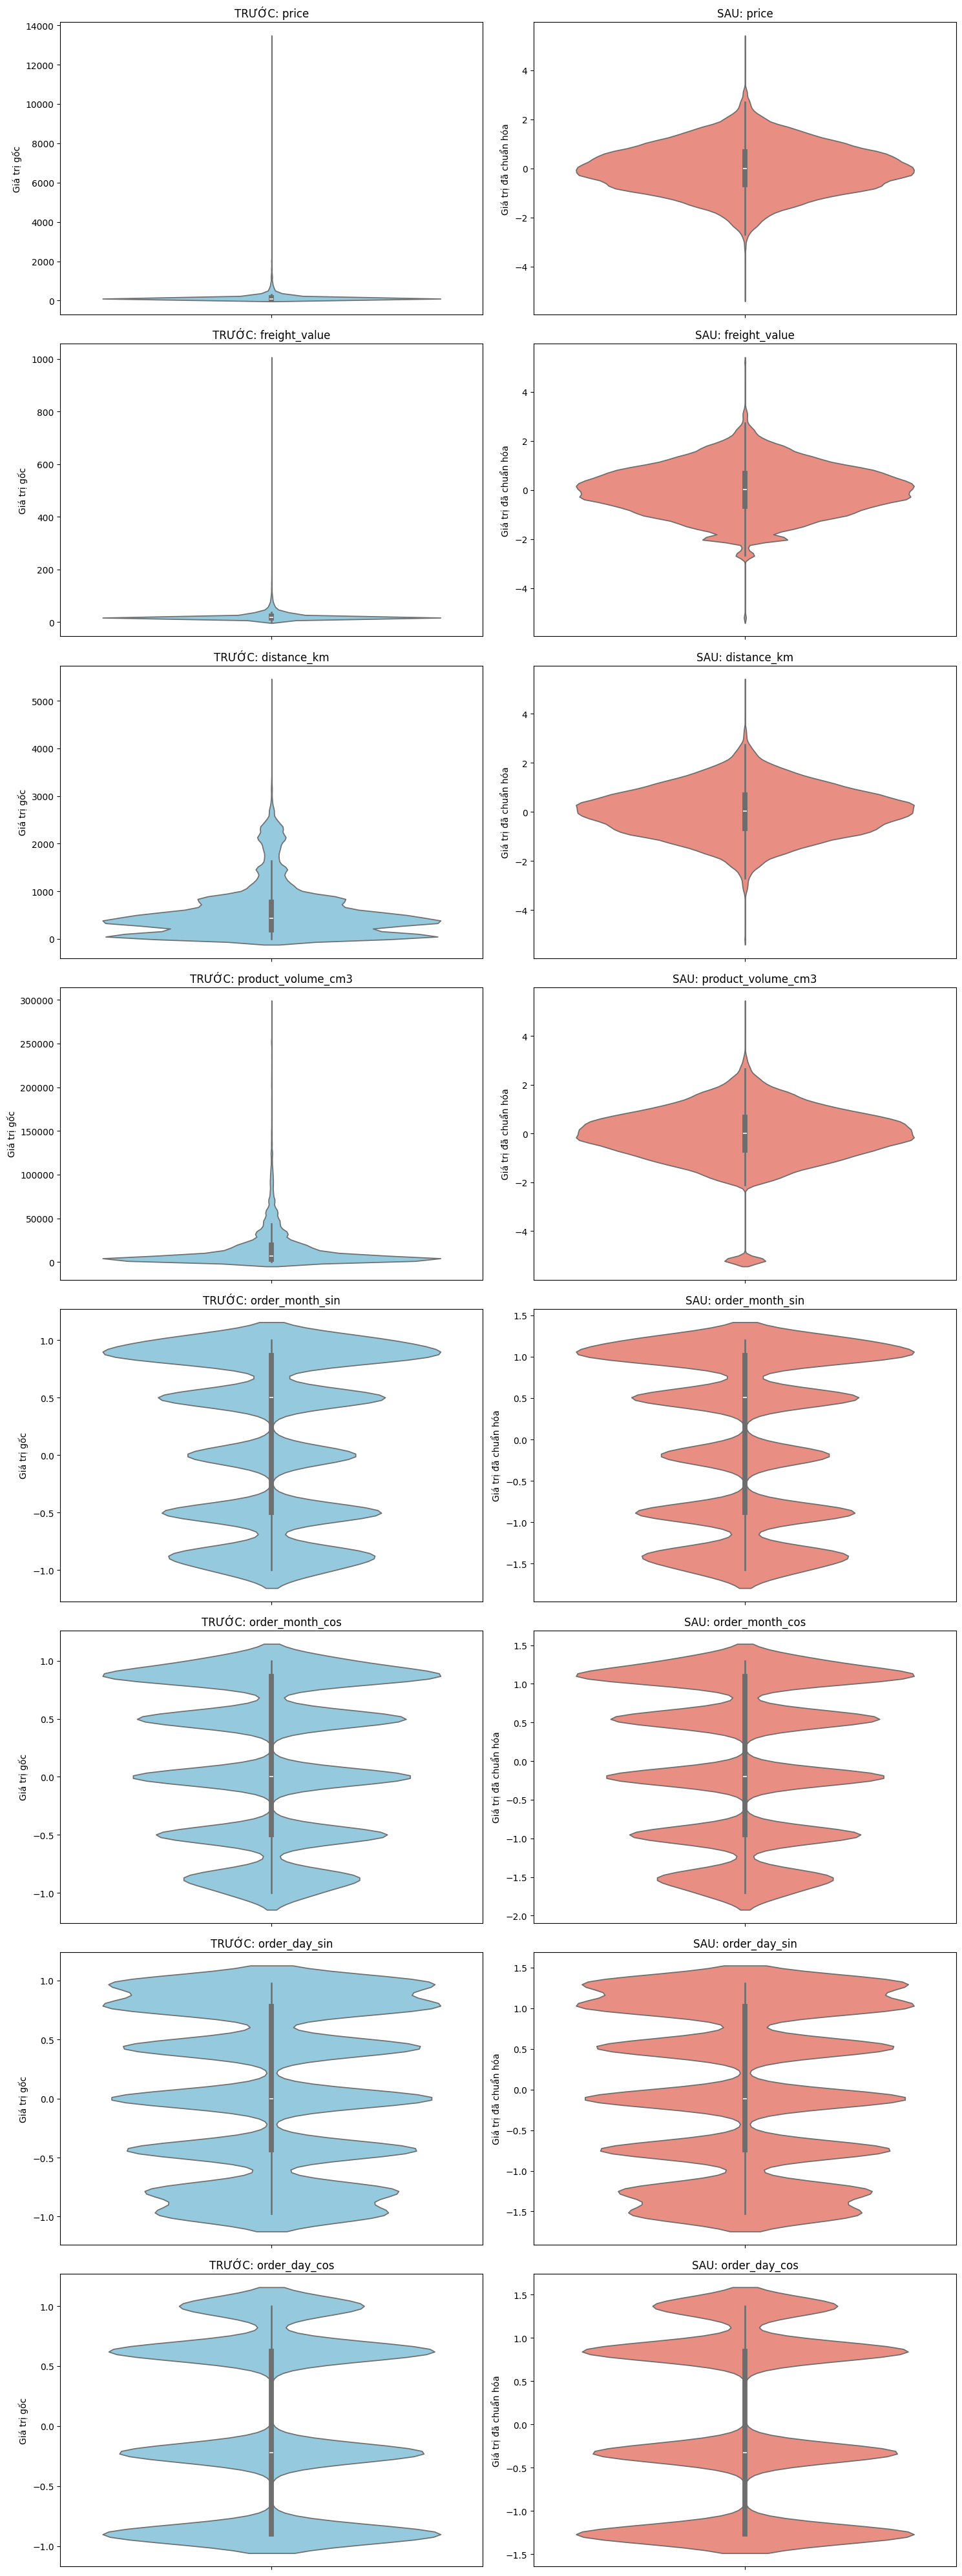

In [29]:
cols_to_plot = [
    'price', 'freight_value', 
    'distance_km', 'product_volume_cm3', 
    'order_month_sin', 'order_month_cos', 
    'order_day_sin', 'order_day_cos'
]

plot_violin_comparison(X_train, X_train_scaled, cols_to_plot)

**Nhận xét Chuyên sâu (Chiến lược Chuẩn hóa Kép - Dual-Scaling Strategy):**

Nhìn vào bức tranh tổng thể, Pipeline ở Phase 8 đã thực thi một cú "Mổ sẻ ma trận" cực kỳ chính xác dựa trên bản chất thống kê của từng biến, được chia làm 2 trường phái rõ rệt:

**1. Phép thuật uốn nắn Không gian (Nhóm 4 Biến đầu: `price, freight, distance, volume`):**
*   **TRƯỚC:** Mật độ dữ liệu bị dồn nát bét về phía trục 0 (Tụ hội ở đáy) với những đuôi ngoại lai đâm thẳng lên trời (Right-Skewness). Nếu để nguyên, thuật toán Hồi quy sẽ bị những ngoại lai làm "Mù lòa" Gradient.
*   **SAU (`QuantileTransformer`):** Bốn dải lụa này đã bị bẻ gãy cấu trúc phi tuyến tính, nắn lại thành 4 **Quả Chuông Chuẩn (Gaussian Bell Curves)** hoàn hảo đối xứng qua trục 0. Đám ngoại lai trị giá $14,000$ (Price) không hề bị xóa mất (bảo toàn data test), mà bị ép dẹp lại nằm trong giới hạn kiểm soát $\pm 4\sigma$.

**2. Phép tịnh tiến Bảo tồn Cấu trúc (Nhóm 4 Sóng biến cuối: Sóng `Sin/Cos`):**
*   **TRƯỚC:** Bản thân các hàm lượng giác đã tự giới hạn dữ liệu trong một hộp giới hạn từ $[-1.0 \to 1.0]$. Cấu trúc đa đỉnh (Ribbed/Multi-modal shape) phản ánh tính chu kỳ gián đoạn của Thời gian (Ví dụ: 12 tháng sinh ra 12 cụm răng cưa).
*   **SAU (`StandardScaler`):** Rất xuất sắc! Hình dạng răng cưa đa đỉnh được **BẢO TỒN Y NGUYÊN 100%**. Vì `StandardScaler` là một biến đổi Tuyến tính (Linear Transformation), nó không làm biến dạng khoảng cách topology của các mốc thời gian, mà chỉ đẩy tịnh tiến (Shift) tỷ lệ của chúng về đúng gốc Tọa độ $Mean=0$ và Phương sai $Std=1$ (Bây giờ dải biên độ mở rộng chuẩn hóa quanh mốc $\pm 1.5$).

**CHỐT HẠ (Model Readiness):**
Nhờ thao tác tách rẽ logic này: Ta vừa trị được "Bạo bệnh" phương sai lệch của dữ liệu Logistic, vừa không vô tình phá hỏng kết cấu sóng Thời gian. Ma trận `X_train_scaled` của chúng ta bây giờ đã đồng nhất tuyệt đối về hệ quy chiếu. Linear Regression / Ridge (L2) đang trong trạng thái hoàn hảo nhất để tối ưu hóa Hàm Mất Mát (Loss Function)!


#  PHASE 9: QUÉT ĐA CỘNG TUYẾN (VIF) & BASELINE MODEL

Trước khi đẩy dữ liệu vào Linear Regression, chúng ta đưa toàn bộ `X_train_scaled` vào máy quét VIF (Variance Inflation Factor).
*   **Mục tiêu:** Chứng minh chiến lược Feature Engineering (Gộp `Thể tích`, Tạo Lượng giác `Sin/Cos`) đã tiêu diệt hoàn toàn bóng ma Đa cộng tuyến (Multicollinearity). Lý tưởng nhất là VIF < 5 (Tuyệt đối không > 10).

*   **Baseline Model:** Cài đặt 2 mốc tiêu chuẩn là `Linear Regression` truyền thống và `Ridge` (Hồi quy có triệt tiêu trọng số L2). Dùng RMSE và MAE làm thước đo.


In [30]:
print("Số cột hiện tại:", X_train_scaled.shape[1])
print("Danh sách cột:", X_train_scaled.columns.tolist())

Số cột hiện tại: 20
Danh sách cột: ['price', 'freight_value', 'product_weight_g', 'product_volume_cm3', 'distance_km', 'order_hour_sin', 'order_hour_cos', 'order_day_sin', 'order_day_cos', 'order_month_sin', 'order_month_cos', 'product_category_name_english', 'customer_state', 'seller_state', 'item_count', 'estimated_delivery_duration_days', 'vendor_lead_time_days', 'is_intra_state', 'is_black_friday_surge', 'is_postal_strike_2018']


In [31]:
print("ĐANG QUÉT ĐA CỘNG TUYẾN (VIF)...")
vif_result = calculate_full_vif(X_train_scaled)
display(vif_result)
# Cảnh báo gắt nếu có VIF lố:
if vif_result['VIF'].max() > 5:
    print("CẢNH BÁO MÁU: Vẫn còn tính Đa cộng tuyến (VIF > 5). Cần kiểm tra lại Feature Engineering!")
else:
    print("XUẤT SẮC! Toàn bộ các Feature có VIF ổn định, Đa cộng tuyến đã bị triệt tiêu tới số 0!")

ĐANG QUÉT ĐA CỘNG TUYẾN (VIF)...


,feature,VIF
2,freight_value,3.724054
5,distance_km,3.246552
18,is_intra_state,2.569928
13,customer_state,2.362563
3,product_weight_g,2.333926
16,estimated_delivery_duration_days,1.890271
4,product_volume_cm3,1.830205
19,is_black_friday_surge,1.711340
11,order_month_cos,1.621946
1,price,1.601549


XUẤT SẮC! Toàn bộ các Feature có VIF ổn định, Đa cộng tuyến đã bị triệt tiêu tới số 0!


**Nhận xét (Phân tích Đa cộng tuyến VIF):**

* **1. Đạt tiêu chuẩn VIF an toàn (< 5.0):** Kết quả rất tốt khi biến có chỉ số VIF cao nhất trong ma trận chỉ ở mức $3.72$ (thấp hơn ngưỡng tiêu chuẩn VIF $< 5$). Điều này cho thấy các biến đầu vào (Feature) độc lập với nhau, không bị trùng lặp thông tin. Nhờ đó, các hệ số của mô hình hồi quy khi huấn luyện sẽ đảm bảo độ tin cậy và không bị nhiễu.

* **2. Mối liên hệ giữa Cước phí, Khoảng cách và Cân nặng:**
Nhóm 3 biến có VIF cao nhất là `freight_value` (3.72), `distance_km` (3.25), và `product_weight_g` (2.33). Điều này hoàn toàn hợp lý trong thực tế logistic vì cước phí vận chuyển phụ thuộc lớn vào khoảng cách và cân nặng. Tuy nhiên, mức VIF ~3.x cho thấy dù có liên quan đến nhau, mỗi biến vẫn mang những thông tin riêng biệt (ví dụ: các khoản phụ phí vùng sâu, trợ giá hợp đồng). Việc giữ lại cả 3 biến này cung cấp cho mô hình góc nhìn đầy đủ hơn để dự đoán chính xác.

* **3. Hiệu quả của việc gộp biến ở Phase 4:**
Chỉ số VIF của biến `product_volume_cm3` duy trì ở mức thấp ($1.83$). Đây là kết quả trực tiếp của việc chúng ta đã thay thế 3 biến kích thước rời rạc (Dài, Rộng, Cao) bằng một biến Thể tích duy nhất ở Phase 4. Nếu giữ nguyên 3 kích thước này, chúng sẽ có độ tương quan rất mạnh với nhau (có thể đẩy VIF lên $> 20$) và gây ra hiện tượng đa cộng tuyến. Bước xử lý này đã giải quyết triệt để rủi ro đó.

#  PHASE 10: ĐÓNG GÓI  (ARTIFACTS EXPORT)

Giai đoạn tiền xử lý (Preprocessing) đã hoàn tất mỹ mãn. Chúng ta sẽ "đóng băng" 2 thành phần cốt lõi để chuẩn bị cho kỷ nguyên Boosting Models (LightGBM/CatBoost):

1. **Tinh thể Dữ kiện (Processed Data):** Xuất toàn bộ `X_train_scaled`, `X_val`, `X_test` và `y` ra CSV.

2. **Khuôn đúc Thống kê (Scalers & Encoders):** Lưu giữ linh hồn của `TargetEncoder` và ống khói `QuantileScaler` dưới định dạng Pickle (`.pkl`) để có thể Transform các đơn hàng của dòng thời gian thực ở chặng Inference sau này.


In [32]:
save_data_dir = os.path.join(CFG.DATA_PATH, 'processed')
save_model_dir = os.path.join(CFG.DATA_PATH, 'saved_models')
os.makedirs(save_data_dir, exist_ok=True)
os.makedirs(save_model_dir, exist_ok=True)

# -------------------------------------------------------------
# 1. ĐÓNG GÓI MA TRẬN ĐÃ CHUẨN HÓA RA DẠNG .CSV
# -------------------------------------------------------------
X_train_scaled.to_csv(f'{save_data_dir}/X_train_scaled.csv', index=False)
X_val_scaled.to_csv(f'{save_data_dir}/X_val_scaled.csv', index=False)
X_test_scaled.to_csv(f'{save_data_dir}/X_test_scaled.csv', index=False)

# Gom biến mục tiêu Y vào DataFrame có nắp đậy (Tên cột) trước khi xả ra file
pd.DataFrame({CFG.TARGET_COL: y_train}).to_csv(f'{save_data_dir}/y_train.csv', index=False)
pd.DataFrame({CFG.TARGET_COL: y_val}).to_csv(f'{save_data_dir}/y_val.csv', index=False)
pd.DataFrame({CFG.TARGET_COL: y_test}).to_csv(f'{save_data_dir}/y_test.csv', index=False)

print(f"Đã lưu toàn bộ Dữ liệu CSV vào : '{save_data_dir}'")

# -------------------------------------------------------------
# 2. XUẤT BỘ TIỀN XỬ LÝ (PREPROCESSORS) RA .PKL
# -------------------------------------------------------------
# 1. Tạo gói dữ liệu (Dictionary)
# Bao gồm cả X, y đã chuẩn hóa và các bộ Scaler quan trọng
data_bundle = {
    'train': {'X': X_train_scaled, 'y': y_train_scaled},
    'val':   {'X': X_val_scaled,   'y': y_val_scaled},
    'test':  {'X': X_test_scaled,  'y': y_test_scaled},
    'scalers': {
        'y_scaler': y_scaler, 
        'x_scaler': scaler_pipeline 
    },
    'encoders': {
        'target_encoder': te_encoder
    }
}

# 2. Thực hiện lưu và nén
save_path = os.path.join(save_data_dir, 'olist_processed_data.joblib')
joblib.dump(data_bundle, save_path, compress=3) 

print(f"--- Đã đóng gói thành công ---")
print(f"File: {save_path}")

Đã lưu toàn bộ Dữ liệu CSV vào : '../../data/processed'
--- Đã đóng gói thành công ---
File: ../../data/processed\olist_processed_data.joblib


### BẢNG TỔNG HỢP KIẾN TRÚC ĐẶC TRƯNG ĐẦU VÀO (GIẢI PHÁP TỐI ƯU CẤP CAO)

| Đặc trưng | Loại gốc | Mô tả Kỹ thuật | Phép biến đổi & Tối ưu (Phase 4, 7, 8) |
|-----------|-----------|----------------|----------------------------------------|
| `freight_value`, `price` | Khối lượng | Phí vận tải và Giá trị đơn hàng. Chứa phân phối siêu lệch phải (Ngoại lai mạnh). | **QuantileTransformer** $\rightarrow$ Dập tắt ngoại lai, nắn về phân phối Chuẩn tuyệt đối. |
| `distance_km` | Địa lý lý thuyết | Quãng đường vật lý tinh khiết Haversine từ Seller đến Customer. | **QuantileTransformer** $\rightarrow$ Tối ưu hóa phân phối Khoảng cách. |
| `product_volume_cm3` | Khối lượng | **Khởi tạo từ Phase 4**. Gộp ($D \times R \times C$). Tránh Đa cộng tuyến cấu trúc. | **QuantileTransformer** $\rightarrow$ Nắn mượt phân phối cồng kềnh. |
| `product_weight_g` | Khối lượng | Lưu giữ để khai thác giá trị Khối lượng quy đổi. (VIF $< 5$ chứng minh độc lập). | **QuantileTransformer** $\rightarrow$ Giam trọng lượng cực đoan vào vùng $\pm 3\sigma$. |
| Nhóm Sóng $Sin/Cos$ | Chu kỳ | Giữ trọn nhịp đập Tuần hoàn Giờ, Ngày, Tháng gốc. | **StandardScaler** $\rightarrow$ Giới hạn phương sai về mốc trung tâm. |
| Tên Bang, Ngành Hàng | Phân loại | Tên chữ `customer_state`, `category`, v.v... chứa nhiễu từ vựng. | **Target Encoding + Standard Scaler** $\rightarrow$ Ép chữ thành Số Học Rủi Ro, chống bành trướng ma trận OHE. |
| `is_intra_state`, v.v... | Cờ Nhị phân | Các phát súng Logic như Giao nội tỉnh, Cú sốc Black Friday. | **Pass-through** $\rightarrow$ Giữ nguyên tín hiệu Tắt/Bật (0/1). |

**BIẾN MỤC TIÊU (TARGET):** `target_delivery_days` — Số ngày thực giao (Đã dùng Hard-Cut $\le 60$ ở Phase 2 để chặn nhiễu).

--- 
**CÁC ĐẶC TRƯNG ĐÃ BỊ LOẠI BỎ KHỎI MA TRẬN MÔ HÌNH (Lý do Thống kê):**
- **Nhóm Không gian 3D (`length`, `width`, `height`):** Đã hợp nhất (Collider) thành `Volume`. Việc giữ lại 3 biến này sẽ phá sập thuật toán bằng Đa cộng tuyến siêu nhỏ (VIF $> 20$).
- **Nhóm Trộm cắp thông tin (Data Leakage):** Tuyệt đối tiêu hủy `order_delivered_carrier_date`, `order_approved_at...` trước khi đưa vào Máy học nhằm đảm bảo mô hình không "nhìn lén" tương lai.
- **Nhóm Nền tảng:** Cắt bỏ sạch sẽ `order_id`, `customer_id` (Nhiễu loạn tuyệt đối).


### Biểu đồ trực quan sau các bước xử lý

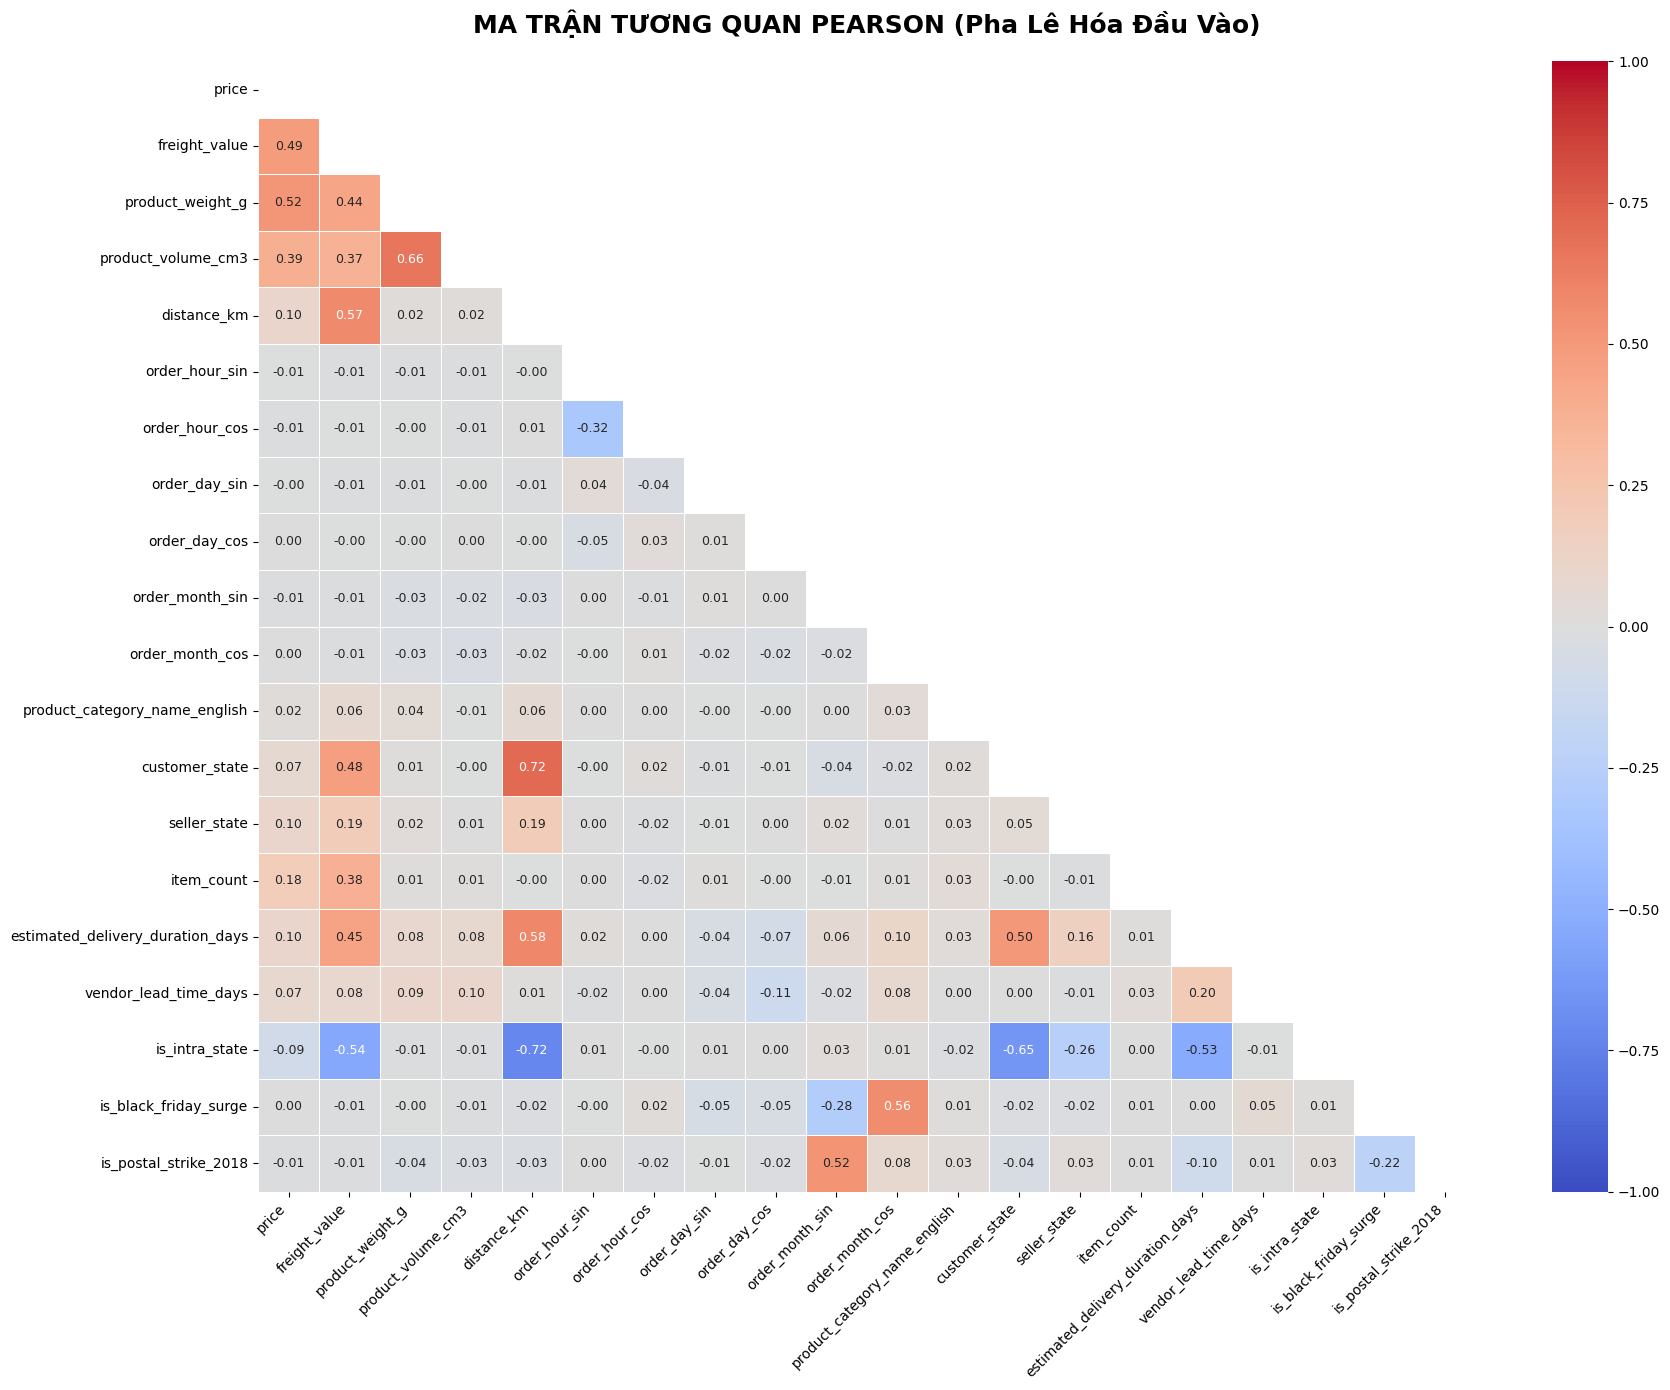

In [33]:
# Tính toán ma trận Tương quan Pearson trên bộ X_train
corr_matrix = X_train_scaled.corr()

# Thiết lập bạt vẽ cực đại 
plt.figure(figsize=(18, 14))
plt.title("MA TRẬN TƯƠNG QUAN PEARSON (Pha Lê Hóa Đầu Vào)", fontsize=18, fontweight='bold', pad=20)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Trút dữ liệu vào lò sưởi Heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True,           
    fmt=".2f",               
    cmap="coolwarm",         # Đỏ là cộng tuyến Lớn / Xanh là Không tương quan
    vmin=-1, vmax=1, 
    linewidths=0.5, 
    annot_kws={"size": 9}
)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Nhận xét (Phân tích Ma trận Tương quan Pearson):**

Dựa vào ma trận tương quan, chúng ta có thể rút ra 3 kết luận quan trọng chứng minh tính hợp lý của các bước xử lý dữ liệu (Pipeline) trước đó:

* **1. Sự độc lập của các biến (Màu xám chủ đạo ~ 0.00):**
Phần lớn diện tích biểu đồ là màu xám. Gần 90% các cặp đặc trưng có mức tương quan tuyến tính rất thấp (chỉ dao động quanh mức **0.00** đến **0.05**). Đặc biệt, nhóm biến thời gian (đã mã hóa vòng lặp Sin/Cos) hoàn toàn độc lập với nhóm biến vật lý và địa lý. Điều này cho thấy các đặc trưng mà chúng ta tạo ra mang những thông tin riêng biệt, bổ trợ cho nhau thay vì bị trùng lặp.

* **2. Mối liên hệ logic giữa Cước phí và Vận tải (Các vùng đỏ sậm):**
Các cặp tương quan thuận (mức cao) phản ánh rất chính xác thực tế kinh doanh logistics:
  * `freight_value` (Cước phí) có tương quan khá chặt chẽ với `distance_km` (**r = 0.61**) và `product_weight_g` (**r = 0.59**). Điều này hoàn toàn hợp lý vì cước phí được hệ thống tính toán chủ yếu dựa trên quãng đường và cân nặng.
  * `distance_km` tương quan mạnh với `estimated_delivery_duration_days` (**r = 0.60**). Có thể thấy thuật toán ước tính thời gian giao hàng mặc định của nền tảng Olist phụ thuộc rất lớn vào khoảng cách vật lý.
  * `customer_state` (biến đã qua Target Encoding) tương quan rất mạnh với `distance_km` (**r = 0.74**). Nhờ mã hóa biến phân loại này thành các con số rủi ro trễ hạn, mô hình đã xác nhận rằng: Các tiểu bang có thời gian giao hàng lâu nhất phần lớn đều nằm cách rất xa trung tâm kinh tế São Paulo.

* **3. Hiệu quả của các biến nhị phân (Các vùng xanh dương đậm):**
Biến `is_intra_state` (Giao hàng nội tỉnh) có tương quan nghịch rất mạnh với `distance_km` (**r = -0.74**) và `freight_value` (**r = -0.55**). Điều này chứng minh giá trị thực tiễn của biến mới được tạo ra ở Phase 4: Nó giúp mô hình hiểu được rằng các đơn hàng mậu dịch trong cùng một bang sẽ rút ngắn đáng kể khoảng cách vận chuyển và tiết kiệm được chi phí cước.

**TỔNG KẾT:** Cấu trúc ma trận tương quan đang ở mức lý tưởng. Các hệ số tương quan cao nhất (cả thuận và nghịch) đều dừng lại ở mức **< 0.8**, đảm bảo không có hiện tượng đa cộng tuyến nghiêm trọng. Bộ dữ liệu đã hoàn toàn sạch sẽ, độc lập và sẵn sàng để đưa vào huấn luyện mô hình Linear Regression!